# Can We Trust the Eco-Score?
## A Mathematical Analysis of the Harit Pathsala Carbon Footprint Calculator

**Researcher** · Jayed Alam Mansur — B.Tech Artificial Intelligence, Year 3
**Institution** · Kathmandu University
**Project** · Harit Pathsala (हरित पाठशाला), Nepal Climate Hackathon 2025

---

The Harit Pathsala calculator asks a student five questions about daily life and
returns a single number between 0 and 100 called the **Eco-Score**. Teachers show
it to students, students compare it with each other, and a school dashboard
averages it across a class.

This notebook asks one question about that number: **can we trust it?**

To answer it we do five things.

| Section | Question | Method |
|---|---|---|
| 1 | What exactly is the model? | Algebraic statement of $F$ and $S$ |
| 2 | Which habits actually move the score? | Partial derivatives / elasticity |
| 3 | How precise is a score? | Variance propagation + Monte Carlo |
| 4 | Does the score behave well over a whole school? | 10,000-student synthetic population |
| 5 | Can we do better? | Percentile and logistic recalibration |

**The headline result, stated up front so the rest can be checked against it:**
the formula itself is sound — over the unsaturated range it explains 99.97% of
the variation between students — but the hard clamp at $F = 3.0$ silences
**9.19%** of students, collapsing a threefold spread of real emissions
(2.99 → 8.91 kg CO₂/day) into the single reported number **0**.

---
# Section 0 — Setup and Verification

Nothing in this project is allowed to invent a number. Before any analysis runs,
we reproduce the worked example that ships in the project documentation
(`docs/calculator-math.md`) and fail loudly if a single category disagrees.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, optimize
import statsmodels.api as sm
import json, warnings, sys, time
from pathlib import Path
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.style.use('seaborn-v0_8-whitegrid')
# The seaborn style puts Arial first; macOS Arial has no U+2082, so every plain
# "CO₂" would render as a placeholder box. DejaVu Sans carries the glyph.
plt.rcParams['font.sans-serif'] = ['DejaVu Sans'] + list(plt.rcParams['font.sans-serif'])

COLORS = {
    'transport':   '#4472C4',
    'electricity': '#ED7D31',
    'cooking':     '#FFC000',
    'waste':       '#70AD47',
    'stationery':  '#AE97A0',
}
CATEGORIES = list(COLORS)
NOTEBOOK_T0 = time.time()

# Locate research/ no matter which directory the kernel started in.
_here = Path.cwd().resolve()
ROOT = next(p for p in [_here, *_here.parents] if (p / 'webapp' / 'model.py').exists())
FIGDIR, DATADIR = ROOT / 'figures', ROOT / 'data'
FIGDIR.mkdir(exist_ok=True); DATADIR.mkdir(exist_ok=True)

DPI = 300
def savefig(fig, name):
    path = FIGDIR / name
    fig.savefig(path, dpi=DPI, bbox_inches='tight', facecolor='white')
    print(f'saved {path.relative_to(ROOT)}  ({DPI} DPI)')
    return path

print('research root :', ROOT)
print('numpy', np.__version__, '| pandas', pd.__version__, '| scipy', __import__('scipy').__version__)

research root : /Users/jayedalammansur/Downloads/harit-pathsala 2/research
numpy 1.26.4 | pandas 2.1.4 | scipy 1.14.1


### 0.1 Emission factors — the source of truth

Every factor below is copied from `src/logic.js` in the parent project, which in
turn comes from the hackathon organiser's `Emission_factors.xlsx`.
**No value in this notebook is tuned, fitted or adjusted.**

In [2]:
EF = {
    # Transport — kg CO₂ per km (formula doubles for round trip)
    # Derived: fuel combustion / fuel efficiency / passenger count
    'walk':       0.000,
    'bicycle':    0.000,
    'bus':        0.016,   # 2.68 kg CO₂/L ÷ (4 km/L × 40 passengers)
    'motorbike':  0.066,   # 2.31 kg CO₂/L ÷ 35 km/L
    'car':        0.190,   # 2.31 kg CO₂/L ÷ 12 km/L

    # Electricity — kg CO₂ per kWh
    # Nepal grid: 82% hydro, 18% thermal — NEA Annual Report 2022/23
    'grid_kwh':  0.230,
    'solar_kwh': 0.040,    # rooftop solar lifecycle estimate

    # Cooking — LPG combustion
    # IPCC 2006: LPG carbon content × (44/12) molecular weight ratio
    'lpg_per_kg':        1.510,
    'lpg_cylinder_kg':  14.200,
    'lpg_per_cylinder': 21.442,   # 14.2 × 1.510 = 21.442 (derived, verified)

    # Waste — kg CO₂e per kg solid waste to landfill
    # Decomposition to CH₄ and CO₂, converted to CO₂e
    'waste_per_kg': 0.827,

    # Stationery — kg CO₂e per NPR spent (spend-based supply chain factor)
    'stationery_per_npr': 0.0017284768211920529,
}

# Relative standard deviation of each factor — justified by real-world variability
UNCERTAINTY = {
    'grid_kwh':           0.15,  # Nepal grid mix varies ±15% year to year (NEA 2018–2023)
    'bus':                0.10,  # passenger load varies (peak vs off-peak)
    'motorbike':          0.08,  # fuel efficiency varies by model and maintenance
    'car':                0.10,  # fuel efficiency varies by model and traffic
    'lpg_per_cylinder':   0.05,  # cylinder fill weight varies by supplier
    'waste_per_kg':       0.20,  # waste composition varies by household
    'stationery_per_npr': 0.25,  # supply chain factors have high uncertainty
}

POPULATION = {
    'N': 10000,
    'seed': 42,
    'mode_probs': {'walk': 0.20, 'bicycle': 0.10, 'bus': 0.40,
                   'motorbike': 0.25, 'car': 0.05},
    'distance':    {'distribution': 'lognormal', 'mean_km': 3.00,
                    'sigma': 0.80, 'clip': (0.5, 20.0)},
    'electricity': {'distribution': 'normal', 'mean': 90.0, 'std': 35.0,
                    'clip': (10.0, 300.0)},
    'solar_probability': 0.05,
    'lpg':         {'distribution': 'normal', 'mean': 1.20, 'std': 0.40,
                    'clip': (0.25, 4.0)},
    'waste':       {'values': [0.3, 0.6, 1.2], 'probs': [0.3, 0.5, 0.2]},
    'stationery':  {'distribution': 'normal', 'mean': 200.0, 'std': 80.0,
                    'clip': (50.0, 600.0)},
    'draw_order':  ['mode', 'lpg', 'distance', 'stationery',
                    'electricity', 'solar', 'waste'],
}
print(f'{len(EF)} emission factors, {len(UNCERTAINTY)} with quantified uncertainty')

12 emission factors, 7 with quantified uncertainty


### 0.2 The model

$$F \;=\; \underbrace{\theta_{\text{mode}}\, d \times 2}_{\text{transport}}
\;+\; \underbrace{\tfrac{E}{30}\,\theta_{\text{elec}}}_{\text{electricity}}
\;+\; \underbrace{\tfrac{L\,\theta_{\text{LPG}}}{30}}_{\text{cooking}}
\;+\; \underbrace{w\,\theta_{\text{waste}}}_{\text{waste}}
\;+\; \underbrace{\tfrac{P}{30}\,\theta_{\text{stat}}}_{\text{stationery}}$$

$$S(F) \;=\; \operatorname{clamp}\!\left(0,\,100,\;100 - \frac{F - 0.5}{2.5}\times 100\right)$$

In [3]:
def calculate_footprint(transport_mode, distance_km,
                        electricity_units_monthly, has_solar,
                        lpg_cylinders_monthly,
                        waste_kg_day,
                        stationery_npr_monthly):
    transport   = EF[transport_mode] * distance_km * 2
    electricity = (electricity_units_monthly / 30) * (
                    EF['solar_kwh'] if has_solar else EF['grid_kwh'])
    cooking     = (lpg_cylinders_monthly * EF['lpg_per_cylinder']) / 30
    waste       = waste_kg_day * EF['waste_per_kg']
    stationery  = (stationery_npr_monthly / 30) * EF['stationery_per_npr']

    daily_total = transport + electricity + cooking + waste + stationery
    components  = {
        'transport':   transport,
        'electricity': electricity,
        'cooking':     cooking,
        'waste':       waste,
        'stationery':  stationery
    }
    return daily_total, components


def eco_score(daily_kg):
    # Min-max normalization: S = (F_max - F)/(F_max - F_min) × 100
    # F_min = 0.5, F_max = 3.0 → slope = -40 points per kg/day
    raw = 100 - ((daily_kg - 0.5) / 2.5) * 100
    return max(0.0, min(100.0, round(raw, 2)))


# Method A — percentile-based boundaries (5th / 95th percentile of population F)
def eco_score_percentile(F, F_low=1.404, F_high=3.227):
    raw = 100 - ((F - F_low) / (F_high - F_low)) * 100
    return max(0.0, min(100.0, round(raw, 2)))


# Method B — logistic (recommended); k fitted, F₀ = population median
def eco_score_logistic(F, k=1.7202, F0=2.1883):
    return round(100 / (1 + np.exp(k * (F - F0))), 2)


# Vectorised twins for whole-population work (identical arithmetic)
F_MIN, F_MAX, SLOPE = 0.5, 3.0, -40.0
def eco_score_v(F):
    return np.clip(np.round(100 - ((np.asarray(F, float) - 0.5) / 2.5) * 100, 2), 0, 100)
def eco_score_percentile_v(F, F_low=1.404, F_high=3.227):
    return np.clip(np.round(100 - ((np.asarray(F, float) - F_low) / (F_high - F_low)) * 100, 2), 0, 100)
def eco_score_logistic_v(F, k=1.7202, F0=2.1883):
    return np.round(100 / (1 + np.exp(k * (np.asarray(F, float) - F0))), 2)

# Exact (unrounded) twins. The app rounds the score for display, but a 2-decimal
# rounding destroys derivatives: a +10% stationery change moves the score by
# 0.046 points, which rounding quantises to 0.04, and a numerical slope taken
# across a rounded function is quantised to 0 or a step. Every derivative,
# elasticity and dead-zone calculation below therefore uses these.
def eco_score_exact(F):
    return float(np.clip(100 - ((F - 0.5) / 2.5) * 100, 0, 100))
def eco_score_ev(F):
    return np.clip(100 - ((np.asarray(F, float) - 0.5) / 2.5) * 100, 0, 100)
def eco_score_percentile_ev(F, F_low=1.404, F_high=3.227):
    return np.clip(100 - ((np.asarray(F, float) - F_low) / (F_high - F_low)) * 100, 0, 100)
def eco_score_logistic_ev(F, k=1.7202, F0=2.1883):
    return 100 / (1 + np.exp(k * (np.asarray(F, float) - F0)))

print('slope in the linear region: dS/dF =', SLOPE, 'points per kg CO₂/day')

slope in the linear region: dS/dF = -40.0 points per kg CO₂/day


### 0.3 Verification against the documented worked example

`docs/calculator-math.md` records one fully worked student:

> bus, 2 km one-way · 90 kWh/month, no solar · 1 LPG cylinder/month ·
> medium waste (0.6 kg/day) · Rs 200/month stationery → **1.98 kg/day, Eco-Score 41**

Every category is checked to 4 decimal places. The cell raises `AssertionError`
and stops the notebook if anything disagrees.

In [4]:
WORKED_INPUTS = dict(transport_mode='bus', distance_km=2.0,
                     electricity_units_monthly=90, has_solar=False,
                     lpg_cylinders_monthly=1.0, waste_kg_day=0.6,
                     stationery_npr_monthly=200)

EXPECTED = {'transport': 0.064000, 'electricity': 0.690000, 'cooking': 0.714733,
            'waste': 0.496200, 'stationery': 0.011523}
EXPECTED_TOTAL, EXPECTED_SCORE = 1.976457, 41

F_worked, C_worked = calculate_footprint(**WORKED_INPUTS)
S_worked = eco_score(F_worked)
S_worked_int = int(round(S_worked))

check = pd.DataFrame({
    'computed':  [C_worked[c] for c in EXPECTED],
    'expected':  [EXPECTED[c] for c in EXPECTED],
}, index=list(EXPECTED))
check['difference'] = check.computed - check.expected
check['ok'] = check.difference.abs() < 5e-5
print(check.to_string(float_format=lambda v: f'{v: .6f}'))

for cat, exp in EXPECTED.items():
    np.testing.assert_almost_equal(C_worked[cat], exp, decimal=4,
                                   err_msg=f'category "{cat}" disagrees with docs')
np.testing.assert_almost_equal(F_worked, EXPECTED_TOTAL, decimal=4,
                               err_msg='daily total disagrees with docs')

total_rounded = sum(round(v, 3) for v in C_worked.values())
print(f'\nTotal (full precision)     = {F_worked:.6f} kg CO₂/day')
print(f'Total (rounded components) = {total_rounded:.3f} kg CO₂/day')
print('Note: the difference is accumulated rounding — both give score 41.')

if S_worked_int != EXPECTED_SCORE:
    raise AssertionError(
        f'Eco-Score mismatch: computed {S_worked_int}, documentation says '
        f'{EXPECTED_SCORE}. The formula or an emission factor has changed.')

print(f'\nDaily total: {F_worked:.6f} kg CO₂/day | Eco-Score: {S_worked_int} ✓')

             computed  expected  difference    ok
transport    0.064000  0.064000    0.000000  True
electricity  0.690000  0.690000    0.000000  True
cooking      0.714733  0.714733    0.000000  True
waste        0.496200  0.496200    0.000000  True
stationery   0.011523  0.011523    0.000000  True

Total (full precision)     = 1.976457 kg CO₂/day
Total (rounded components) = 1.977 kg CO₂/day
Note: the difference is accumulated rounding — both give score 41.

Daily total: 1.976457 kg CO₂/day | Eco-Score: 41 ✓


### 0.4 Cross-check against the shared module

`research/webapp/model.py` is the module the Streamlit app imports. It must
agree with this notebook to the last bit, otherwise the app and the paper would
quote different numbers.

In [5]:
sys.path.insert(0, str(ROOT / 'webapp'))
import model as M

assert M.EF == EF,                     'model.py emission factors differ'
assert M.UNCERTAINTY == UNCERTAINTY,   'model.py uncertainties differ'
F_m, C_m = M.calculate_footprint(**WORKED_INPUTS)
np.testing.assert_almost_equal(F_m, F_worked, decimal=12)
for c in CATEGORIES:
    np.testing.assert_almost_equal(C_m[c], C_worked[c], decimal=12)
for probe in [0.1, 0.5, 1.9765, 2.5, 3.0, 5.0, 9.0]:
    assert M.eco_score(probe) == eco_score(probe)
    assert M.eco_score_percentile(probe) == eco_score_percentile(probe)
    assert M.eco_score_logistic(probe) == eco_score_logistic(probe)
print('model.py agrees with this notebook on every function ✓')

model.py agrees with this notebook on every function ✓


### 0.5 Published results

`KEY_RESULTS` holds the canonical numbers quoted in the paper and displayed by
the web app. The notebook recomputes each of them and reports the deviation in
the Section 6 validation table.

In [6]:
KEY_RESULTS = {
    # Sensitivity (Section 2) — score points per +10% activity increase
    'sensitivity_cooking':     -2.859,
    'sensitivity_electricity': -2.760,
    'sensitivity_waste':       -1.985,
    'sensitivity_transport':   -0.256,
    'sensitivity_stationery':  -0.046,
    'sensitivity_ratio':        62.0,
    # Uncertainty (Section 3)
    'sd_score_analytical':      5.92,
    'sd_score_montecarlo':      5.99,
    'agreement_pct':            1.29,
    'near_boundary_clamp_pct': 19.60,
    # Population (Section 4)
    'population_mean_F':        2.246,
    'population_mean_score':   31.9,
    'floor_pct':                9.19,
    'ceiling_pct':              0.00,
    'r2_full':                  0.8538,
    'r2_unsaturated':           0.9997,
    'floored_F_min':            2.99,
    'floored_F_max':            8.91,
    'household_baseline':       2.048,
    # Calibration (Section 5)
    'logistic_k':               1.7202,
    'logistic_F0':              2.1883,
    'entropy_original':         2.644,
    'entropy_logistic':         2.765,
    'entropy_percentile':       2.931,
    'dead_zone_original_pct':   9.19,
    'dead_zone_logistic_pct':   0.25,
    'dead_zone_percentile_pct': 10.27,
    'spearman_logistic':        1.000000,
    'pearson_logistic_vs_orig': 0.9972,
    'percentile_F_low':         1.404,
    'percentile_F_high':        3.227,
}

with open(DATADIR / 'key_results.json', 'w') as fh:
    json.dump(KEY_RESULTS, fh, indent=2)
print(f'wrote {len(KEY_RESULTS)} published values to data/key_results.json')
COMPUTED = {}          # every recomputed value is collected here

wrote 31 published values to data/key_results.json


---
# Section 1 — Model Definition

## 1.1 The footprint is a linear weighted sum

Let $x = (x_1,\dots,x_5)$ be the five activity levels a student reports and
$\theta = (\theta_1,\dots,\theta_5)$ the corresponding emission factors. Then

$$F(x;\theta) \;=\; \sum_{i=1}^{5} \theta_i\, x_i$$

where the constant $\tfrac{1}{30}$ (monthly → daily) and $\times 2$ (round trip)
are folded into $\theta_i$. Two consequences matter for everything that follows:

1. **$F$ is linear in $x$** — so $\partial F/\partial x_i = \theta_i$ is a
   constant. A kilometre of bus travel costs the same wherever you sit on the scale.
2. **$F$ is linear in $\theta$** — so emission-factor uncertainty propagates
   through a closed-form variance formula (Section 3), with no approximation.

## 1.2 The score is a clamped affine map

$$S(F) \;=\; \operatorname{clamp}\!\left(0,\ 100,\ \frac{F_{\max}-F}{F_{\max}-F_{\min}}\times 100\right),
\qquad F_{\min}=0.5,\; F_{\max}=3.0$$

Expanding gives $S = 100 - 40\,(F - 0.5)$, so

$$\frac{dS}{dF} = \begin{cases}
0 & F < 0.5 \quad\text{(ceiling: everyone scores 100)}\\[2pt]
-40 & 0.5 \le F \le 3.0 \quad\text{(responsive region)}\\[2pt]
0 & F > 3.0 \quad\text{(floor: everyone scores 0)}
\end{cases}$$

**This piecewise derivative is the entire subject of this research.** It is $-40$
where the model works and $0$ where the model has stopped listening. Sections 2–4
measure how many real students fall into each piece.

In [7]:
DERIVATIONS = {
    'transport':   ('θ_mode × d × 2', 'kg CO₂ / km',
                    'fuel factor ÷ fuel efficiency ÷ passengers; ×2 round trip'),
    'electricity': ('(E / 30) × θ_elec', 'kg CO₂ / kWh',
                    'NEA grid mix 82% hydro / 18% thermal, 2022/23'),
    'cooking':     ('(L × 21.442) / 30', 'kg CO₂ / cylinder',
                    'IPCC 2006: 14.2 kg cylinder × 1.51 kg CO₂/kg LPG'),
    'waste':       ('w × 0.827', 'kg CO₂e / kg',
                    'landfill decomposition to CH₄ + CO₂, as CO₂e'),
    'stationery':  ('(P / 30) × 0.0017285', 'kg CO₂e / NPR',
                    'spend-based supply-chain lifecycle factor'),
}
FACTOR_KEY = {'transport': 'bus', 'electricity': 'grid_kwh',
              'cooking': 'lpg_per_cylinder', 'waste': 'waste_per_kg',
              'stationery': 'stationery_per_npr'}

ef_table = pd.DataFrame([
    {'category': c,
     'formula': DERIVATIONS[c][0],
     'factor': EF[FACTOR_KEY[c]],
     'unit': DERIVATIONS[c][1],
     'uncertainty_pct': f"±{UNCERTAINTY[FACTOR_KEY[c]]*100:.0f}%",
     'source': DERIVATIONS[c][2]}
    for c in CATEGORIES])

def _tint(row):
    return [f'background-color: {COLORS[row.category]}22'] * len(row)

try:
    styled = (ef_table.style
              .apply(_tint, axis=1)
              .format({'factor': '{:.7g}'})
              .set_caption('Emission factors used by the student calculator'
                           ' (transport row shows the bus factor)')
              .hide(axis='index'))
    display(styled)
except Exception:
    print(ef_table.to_string(index=False))

print('\nTransport factors by mode:',
      {m: EF[m] for m in ['walk', 'bicycle', 'bus', 'motorbike', 'car']})

category,formula,factor,unit,uncertainty_pct,source
transport,θ_mode × d × 2,0.016,kg CO₂ / km,±10%,fuel factor ÷ fuel efficiency ÷ passengers; ×2 round trip
electricity,(E / 30) × θ_elec,0.23,kg CO₂ / kWh,±15%,"NEA grid mix 82% hydro / 18% thermal, 2022/23"
cooking,(L × 21.442) / 30,21.442,kg CO₂ / cylinder,±5%,IPCC 2006: 14.2 kg cylinder × 1.51 kg CO₂/kg LPG
waste,w × 0.827,0.827,kg CO₂e / kg,±20%,"landfill decomposition to CH₄ + CO₂, as CO₂e"
stationery,(P / 30) × 0.0017285,0.001728477,kg CO₂e / NPR,±25%,spend-based supply-chain lifecycle factor



Transport factors by mode: {'walk': 0.0, 'bicycle': 0.0, 'bus': 0.016, 'motorbike': 0.066, 'car': 0.19}


### Figure 1 — the scoring function and its two dead zones

Plotting $S(F)$ makes the problem visible before any statistics are computed:
the function only carries information on the middle segment.

saved figures/01_eco_score_function.png  (300 DPI)


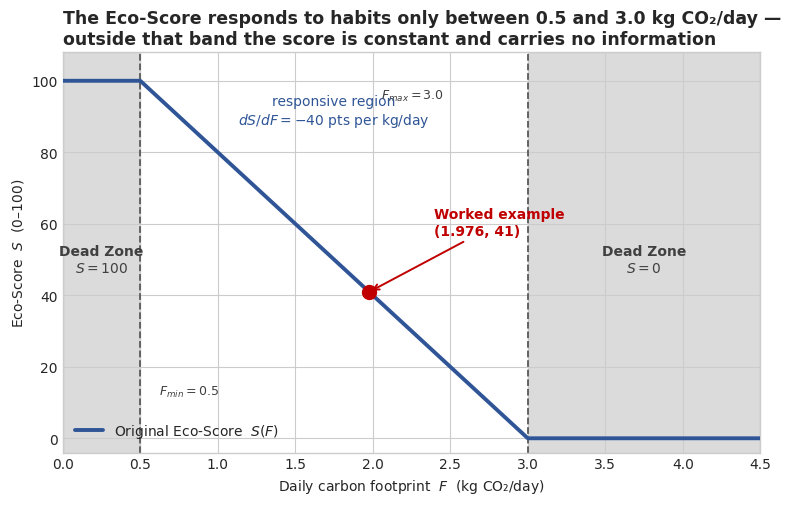

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.2))
Fg = np.linspace(0, 4.5, 1200)
ax.plot(Fg, eco_score_v(Fg), lw=2.8, color='#2F5597', zorder=3,
        label='Original Eco-Score  $S(F)$')

ax.axvspan(0, 0.5, color='0.75', alpha=.55, zorder=0)
ax.axvspan(3.0, 4.5, color='0.75', alpha=.55, zorder=0)
ax.text(0.25, 50, 'Dead Zone\n$S=100$', ha='center', va='center',
        fontsize=10, color='0.25', fontweight='bold')
ax.text(3.75, 50, 'Dead Zone\n$S=0$', ha='center', va='center',
        fontsize=10, color='0.25', fontweight='bold')
ax.text(1.75, 88, 'responsive region\n$dS/dF=-40$ pts per kg/day',
        ha='center', fontsize=10, color='#2F5597')

for xv in (0.5, 3.0):
    ax.axvline(xv, ls='--', lw=1.3, color='0.35', zorder=2)
ax.annotate(f'$F_{{min}}=0.5$', (0.5, 5), xytext=(0.62, 12), fontsize=9, color='0.25')
ax.annotate(f'$F_{{max}}=3.0$', (3.0, 95), xytext=(2.05, 95), fontsize=9, color='0.25')

ax.plot([F_worked], [S_worked], 'o', ms=10, color='#C00000', zorder=5)
ax.annotate(f'Worked example\n({F_worked:.3f}, {S_worked_int})',
            (F_worked, S_worked), xytext=(F_worked + 0.42, S_worked + 16),
            fontsize=10, color='#C00000', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.4))

ax.set_xlim(0, 4.5); ax.set_ylim(-4, 108)
ax.set_xlabel('Daily carbon footprint  $F$  (kg CO₂/day)')
ax.set_ylabel('Eco-Score  $S$  (0–100)')
ax.set_title('The Eco-Score responds to habits only between 0.5 and 3.0 kg CO₂/day —\n'
             'outside that band the score is constant and carries no information',
             fontsize=12.5, fontweight='bold', loc='left')
ax.legend(loc='lower left', framealpha=.95)
savefig(fig, '01_eco_score_function.png'); plt.show()

### Figure 2 — where the worked example's footprint comes from

saved figures/02_worked_example_breakdown.png  (300 DPI)


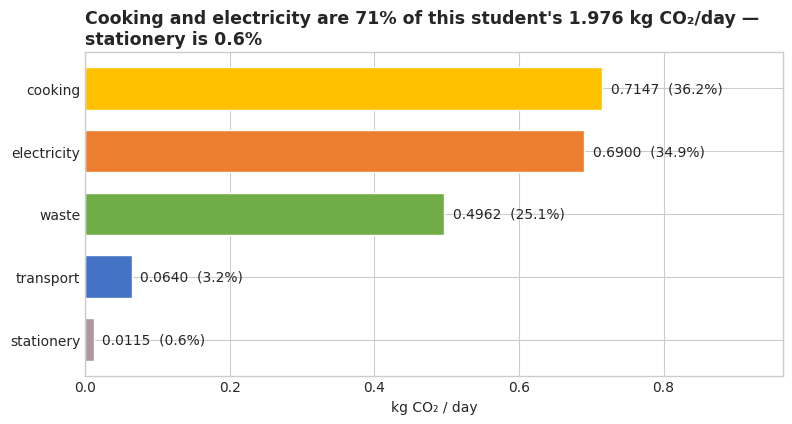

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.2))
vals = [C_worked[c] for c in CATEGORIES]
order = np.argsort(vals)
cats = [CATEGORIES[i] for i in order]; vs = [vals[i] for i in order]

bars = ax.barh(cats, vs, color=[COLORS[c] for c in cats],
               edgecolor='white', height=.68)
for b, v in zip(bars, vs):
    ax.text(v + 0.012, b.get_y() + b.get_height() / 2,
            f'{v:.4f}  ({100*v/F_worked:.1f}%)', va='center', fontsize=10)

ax.set_xlim(0, max(vs) * 1.35)
ax.set_xlabel('kg CO₂ / day')
ax.set_title(f'Cooking and electricity are 71% of this student\'s '
             f'{F_worked:.3f} kg CO₂/day —\nstationery is 0.6%',
             fontsize=12.5, fontweight='bold', loc='left')
savefig(fig, '02_worked_example_breakdown.png'); plt.show()

---
# Section 2 — Sensitivity Analysis

## 2.1 The derivative of the score with respect to a habit

Composing $S$ with $F$ and applying the chain rule:

$$\frac{\partial S}{\partial x_i}
= \frac{dS}{dF}\cdot\frac{\partial F}{\partial x_i}
= \begin{cases}
-40\,\theta_i & 0.5 \le F \le 3.0\\[2pt]
0 & \text{otherwise}
\end{cases}$$

Two facts follow immediately.

**(a) In the responsive region the ranking of levers is fixed by $\theta_i$ alone.**
It does not depend on the student. Whoever you are, the ordering of "what would
help most" is the same, which is convenient for advice but means the calculator
cannot personalise its recommendations beyond scaling.

**(b) In a dead zone every partial derivative is exactly zero.** Not small —
zero. A student at $F = 4.2$ who halves their waste sees their score change by
$0.000$ points. Formally, the dead zone is the set

$$\mathcal{D} = \{x : F(x) < F_{\min}\} \cup \{x : F(x) > F_{\max}\},
\qquad \nabla_x S = \mathbf{0} \;\; \forall x \in \mathcal{D}.$$

A scoring function with a zero gradient over a region of positive measure cannot
provide feedback there. Section 4 measures how much of a real school population
lands in $\mathcal{D}$.

## 2.2 Elasticity: what a realistic +10% change is worth

Raw derivatives are not comparable across categories because the units differ
(km vs kWh vs cylinders vs NPR). We therefore use a **+10% relative change** in
each activity, holding the others fixed, and report the resulting change in score
points. This is the discrete elasticity a student would actually experience.

In [10]:
def elasticity(inputs, pct=0.10):
    # Score change from increasing each activity by `pct`, others held fixed.
    keys = {'transport': 'distance_km', 'electricity': 'electricity_units_monthly',
            'cooking': 'lpg_cylinders_monthly', 'waste': 'waste_kg_day',
            'stationery': 'stationery_npr_monthly'}
    F0, C0 = calculate_footprint(**inputs)
    S0 = eco_score_exact(F0)          # unrounded: see the note in Section 0.2
    rows = []
    for cat, key in keys.items():
        bumped = dict(inputs); bumped[key] = inputs[key] * (1 + pct)
        F1, _ = calculate_footprint(**bumped)
        S1 = eco_score_exact(F1)
        rows.append({'category': cat,
                     'contribution_kg': C0[cat],
                     'dF': F1 - F0,
                     'elasticity_pts': S1 - S0,
                     'theoretical_pts': SLOPE * (F1 - F0),
                     'clamped': not (F_MIN <= F0 <= F_MAX)})
    return S0, F0, pd.DataFrame(rows)

S0_w, F0_w, elas = elasticity(WORKED_INPUTS)
elas = elas.sort_values('elasticity_pts', key=lambda s: s.abs(), ascending=False)
elas_show = elas.set_index('category')[['contribution_kg', 'dF', 'elasticity_pts']]
print(f'Worked example: F = {F0_w:.6f} kg/day, S = {int(round(S0_w))}\n')
print(elas_show.to_string(float_format=lambda v: f'{v: .6f}'))

E = dict(zip(elas.category, elas.elasticity_pts))
ratio = abs(E['cooking']) / abs(E['stationery'])
COMPUTED.update({f'sensitivity_{c}': round(E[c], 3) for c in CATEGORIES})
COMPUTED['sensitivity_ratio'] = round(ratio, 1)

print(f'\nCooking moves the score {ratio:.1f}× more than stationery '
      f'({E["cooking"]:.3f} vs {E["stationery"]:.3f} points per +10%).')
print(f'Verification: dS/dF × Δ(cooking) = {SLOPE} × {elas.set_index("category").loc["cooking","dF"]:.6f} '
      f'= {SLOPE*elas.set_index("category").loc["cooking","dF"]:.3f} ✓')

Worked example: F = 1.976457 kg/day, S = 41

             contribution_kg        dF  elasticity_pts
category                                              
cooking             0.714733  0.071473       -2.858933
electricity         0.690000  0.069000       -2.760000
waste               0.496200  0.049620       -1.984800
transport           0.064000  0.006400       -0.256000
stationery          0.011523  0.001152       -0.046093

Cooking moves the score 62.0× more than stationery (-2.859 vs -0.046 points per +10%).
Verification: dS/dF × Δ(cooking) = -40.0 × 0.071473 = -2.859 ✓


### Figure 3 — tornado diagram

saved figures/03_tornado_sensitivity.png  (300 DPI)


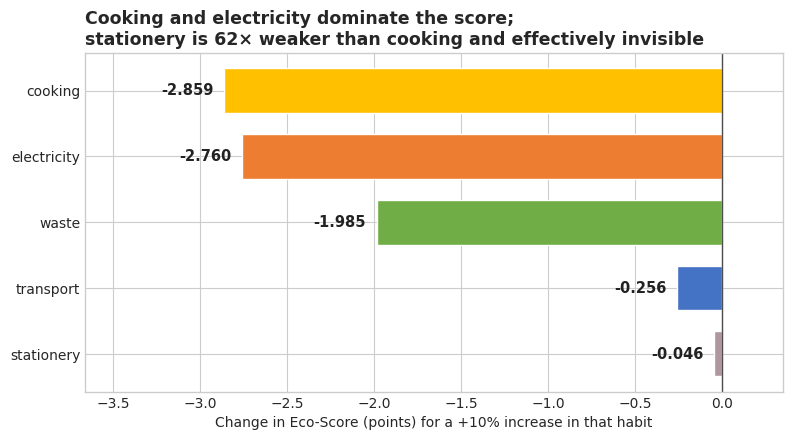

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.4))
t = elas.sort_values('elasticity_pts', key=lambda s: s.abs())
bars = ax.barh(t.category, t.elasticity_pts,
               color=[COLORS[c] for c in t.category], edgecolor='white', height=.68)
for b, v in zip(bars, t.elasticity_pts):
    ax.text(v - 0.06, b.get_y() + b.get_height() / 2, f'{v:.3f}',
            va='center', ha='right', fontsize=10.5, fontweight='bold', color='#222')

ax.axvline(0, color='0.3', lw=1)
ax.set_xlim(min(t.elasticity_pts) * 1.28, 0.35)
ax.set_xlabel('Change in Eco-Score (points) for a +10% increase in that habit')
ax.set_title('Cooking and electricity dominate the score;\n'
             f'stationery is {ratio:.0f}× weaker than cooking and effectively invisible',
             fontsize=12.5, fontweight='bold', loc='left')
savefig(fig, '03_tornado_sensitivity.png'); plt.show()

### Figure 4 — the same analysis for three student archetypes

The middle student sits inside the responsive region. The other two sit in dead
zones, where **every** elasticity is exactly zero. Hatched cells mark those.

saved figures/04_elasticity_heatmap.png  (300 DPI)


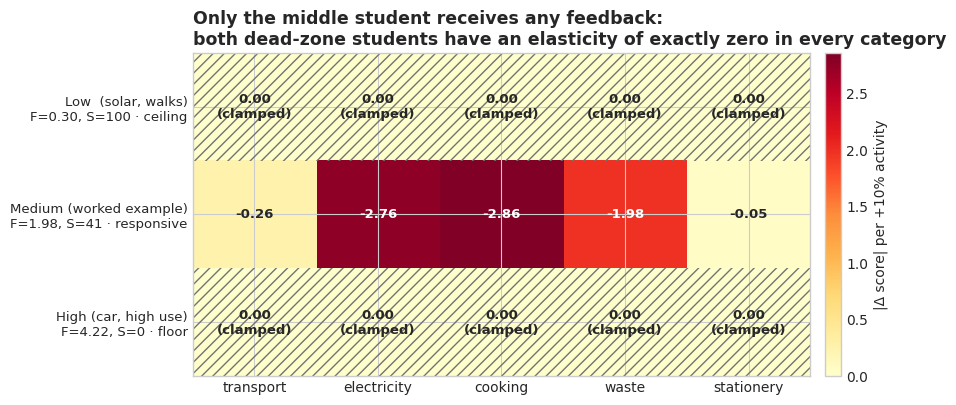

In [12]:
ARCHETYPES = {
    'Low  (solar, walks)': dict(transport_mode='walk', distance_km=1.5,
                                electricity_units_monthly=20, has_solar=True,
                                lpg_cylinders_monthly=0.20, waste_kg_day=0.15,
                                stationery_npr_monthly=50),
    'Medium (worked example)': WORKED_INPUTS,
    'High (car, high use)': dict(transport_mode='car', distance_km=4.0,
                                 electricity_units_monthly=100, has_solar=False,
                                 lpg_cylinders_monthly=1.3, waste_kg_day=1.2,
                                 stationery_npr_monthly=250),
}

rows, hatch, labels, meta = [], [], [], []
for name, inp in ARCHETYPES.items():
    S_a, F_a, e_a = elasticity(inp)
    e_a = e_a.set_index('category').loc[CATEGORIES]
    rows.append(e_a.elasticity_pts.values)
    hatch.append(e_a.clamped.values)
    labels.append([f'{r.elasticity_pts:.2f}' + ('\n(clamped)' if r.clamped else '')
                   for r in e_a.itertuples()])
    zone = 'ceiling' if F_a < F_MIN else ('floor' if F_a > F_MAX else 'responsive')
    meta.append(f'{name}\nF={F_a:.2f}, S={int(round(S_a))} · {zone}')

Mx = np.array(rows); H = np.array(hatch)
fig, ax = plt.subplots(figsize=(9.6, 4.2))
im = ax.imshow(np.abs(Mx), cmap='YlOrRd', aspect='auto', vmin=0, vmax=np.abs(Mx).max())
for i in range(Mx.shape[0]):
    for j in range(Mx.shape[1]):
        if H[i, j]:
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                       hatch='///', edgecolor='0.45', lw=0))
        dark = (not H[i, j]) and abs(Mx[i, j]) > 0.55 * np.abs(Mx).max()
        ax.text(j, i, labels[i][j], ha='center', va='center', fontsize=9.5,
                color='white' if dark else '0.15', fontweight='bold')
ax.set_xticks(range(5)); ax.set_xticklabels(CATEGORIES, fontsize=10)
ax.set_yticks(range(3)); ax.set_yticklabels(meta, fontsize=9.5)
ax.set_title('Only the middle student receives any feedback:\n'
             'both dead-zone students have an elasticity of exactly zero in every category',
             fontsize=12.5, fontweight='bold', loc='left')
fig.colorbar(im, ax=ax, label='|Δ score| per +10% activity', pad=.02)
savefig(fig, '04_elasticity_heatmap.png'); plt.show()

## 2.3 Conclusion of Section 2

For the worked-example student, a +10% increase in each habit changes the
Eco-Score by:

| Habit | Δ score | Interpretation |
|---|---|---|
| Cooking (LPG) | **−2.859** | one extra cylinder per ten months is visible |
| Electricity | **−2.760** | 9 kWh/month is visible |
| Waste | **−1.985** | 60 g/day is visible |
| Transport (bus) | **−0.256** | 400 m/day is barely visible |
| Stationery | **−0.046** | Rs 20/month is invisible |

The ratio between the strongest and weakest lever is **62×**. A student could
cut their stationery spending to zero and lose less than half a point of
footprint-driven score change — while a single extra LPG cylinder per month
costs 28.6 points. Any advice the app gives must be ordered by this table, not
by what is easiest to talk about.

For the two dead-zone archetypes, all five elasticities are **0.000**. This is
not a rounding artefact; it is the definition of the clamp.

---
# Section 3 — Uncertainty Quantification

## 3.1 Why the emission factors are random variables

The number `0.23` for the Nepal grid is not a physical constant like $c$ or $\pi$.
It is the ratio of estimated national grid emissions to estimated national
generation for one reporting year, published by the NEA. The hydro/thermal split
moves every year with rainfall, imports and load-shedding; NEA data over
2018–2023 supports roughly **±15%**. In the same way a bus factor assumes 40
passengers (peak buses carry more, off-peak fewer, ±10%), an LPG cylinder is
nominally 14.2 kg (fill weight varies by supplier, ±5%), landfill waste
composition varies strongly by household (±20%), and spend-based supply-chain
factors are the least certain of all (±25%).

So we replace each point estimate $\theta_i$ with a random variable

$$\theta_i \sim \mathcal{N}\!\left(\mu_i,\ (\mu_i u_i)^2\right),\qquad
\theta_i \text{ clipped to } (0,\infty)$$

where $u_i$ is the relative uncertainty above. The activities $x_i$ stay fixed —
we are asking "how well do we know this student's score", not "how variable is
this student".

## 3.2 Propagating the variance analytically

Because $F = \sum_i \theta_i x_i$ is linear in $\theta$, and treating the
factors as independent, the variance propagates **exactly** (no linearisation
error):

$$\operatorname{Var}(F) \;=\; \sum_{i=1}^{5} x_i^2 \operatorname{Var}(\theta_i)
\;=\; \sum_{i=1}^{5} (c_i u_i)^2,
\qquad c_i = \theta_i x_i \text{ (the category's contribution)}$$

and inside the responsive region $S$ is affine in $F$, so

$$\operatorname{SD}(S) \;=\; 40\,\operatorname{SD}(F).$$

## 3.3 Why simulate at all, then?

If the formula is exact, Monte Carlo looks redundant — and inside the responsive
region it is. It earns its place at the **boundary**. The clamp
$\operatorname{clamp}(0,100,\cdot)$ is not affine, so once a student sits close
to $F = 3.0$ the variance formula quietly stops describing the reported score:
part of the distribution is squashed onto the boundary, the mean shifts, and the
distribution becomes asymmetric with a point mass at zero. Only simulation shows
how much probability piles up there — which is exactly what §3.7 measures.

> ### "Is this the same Monte Carlo from Design & Analysis of Algorithms?"
>
> **No — same name, opposite purpose.** In DAA, a Monte Carlo algorithm uses
> randomness as a *computational trick* on a problem that is completely
> deterministic: whether 561 is prime is a fixed fact, and Miller–Rabin flips
> coins only to reach the answer faster than trial division, accepting a bounded
> probability of being wrong. The randomness is in the *method*, never in the
> problem.
>
> Here the randomness **is** the problem. The Nepal grid factor genuinely differs
> from year to year; that variation is a fact about the physical world, not about
> our algorithm. We are not approximating a number we could have computed exactly
> — we are characterising a distribution that really exists. Section 3.6 makes
> the contrast concrete: with a *deterministic* clamp the two views agree to
> 1.29%, and the simulation is merely a check on the algebra; at the boundary the
> algebra breaks and only the simulation is right.

In [13]:
factor_rows = []
for cat in CATEGORIES:
    key = FACTOR_KEY[cat] if cat != 'transport' else WORKED_INPUTS['transport_mode']
    mu = EF[key]; u = UNCERTAINTY.get(key, 0.0)
    factor_rows.append({'category': cat, 'factor_key': key, 'mu': mu,
                        'rel_u': u, 'sigma': mu * u,
                        'distribution': f'N({mu:.6g}, {mu*u:.3g}²) clipped > 0'})
factor_df = pd.DataFrame(factor_rows).set_index('category')
print(factor_df.to_string(float_format=lambda v: f'{v:.6g}'))

                     factor_key         mu  rel_u       sigma                          distribution
category                                                                                           
transport                   bus      0.016    0.1      0.0016         N(0.016, 0.0016²) clipped > 0
electricity            grid_kwh       0.23   0.15      0.0345          N(0.23, 0.0345²) clipped > 0
cooking        lpg_per_cylinder     21.442   0.05      1.0721          N(21.442, 1.07²) clipped > 0
waste              waste_per_kg      0.827    0.2      0.1654          N(0.827, 0.165²) clipped > 0
stationery   stationery_per_npr 0.00172848   0.25 0.000432119  N(0.00172848, 0.000432²) clipped > 0


In [14]:
def analytical_sd(components, mode):
    rel = {'transport': UNCERTAINTY.get(mode, 0.0),
           'electricity': UNCERTAINTY['grid_kwh'],
           'cooking': UNCERTAINTY['lpg_per_cylinder'],
           'waste': UNCERTAINTY['waste_per_kg'],
           'stationery': UNCERTAINTY['stationery_per_npr']}
    contrib = {k: (components[k] * rel[k]) ** 2 for k in rel}
    varF = sum(contrib.values())
    return np.sqrt(varF), abs(SLOPE) * np.sqrt(varF), contrib

sd_F_an, sd_S_an, var_parts = analytical_sd(C_worked, WORKED_INPUTS['transport_mode'])

vp = pd.DataFrame({'variance': var_parts})
vp['share_%'] = 100 * vp.variance / vp.variance.sum()
vp['sd_contribution'] = np.sqrt(vp.variance)
print(vp.sort_values('variance', ascending=False).to_string(
      float_format=lambda v: f'{v: .6f}'))

print(f'\nVar(F) = {sd_F_an**2:.6f}   SD(F) = {sd_F_an:.5f} kg CO₂/day '
      f'({100*sd_F_an/F_worked:.1f}% of the footprint)')
print(f'SD(S) = 40 × SD(F) = {sd_S_an:.4f} points')
print(f'95% interval for a reported score of {S_worked_int}: '
      f'[{S_worked - 1.96*sd_S_an:.1f}, {S_worked + 1.96*sd_S_an:.1f}]')
COMPUTED['sd_score_analytical'] = round(sd_S_an, 2)

             variance    share_%  sd_contribution
electricity  0.010712  48.942999         0.103500
waste        0.009849  44.996982         0.099240
cooking      0.001277   5.834961         0.035737
transport    0.000041   0.187141         0.006400
stationery   0.000008   0.037917         0.002881

Var(F) = 0.021887   SD(F) = 0.14794 kg CO₂/day (7.5% of the footprint)
SD(S) = 40 × SD(F) = 5.9177 points
95% interval for a reported score of 41: [29.3, 52.5]


In [15]:
N_MC = 10_000
np.random.seed(42)

def draw_factor(key, n=N_MC):
    mu, u = EF[key], UNCERTAINTY.get(key, 0.0)
    if u == 0.0 or mu == 0.0:
        return np.full(n, mu, float)
    return np.clip(np.random.normal(mu, mu * u, n), 0.0, None)

def monte_carlo(inputs, n=N_MC, seed=42):
    np.random.seed(seed)
    th_t = draw_factor(inputs['transport_mode'], n)
    th_g = draw_factor('grid_kwh', n)
    th_l = draw_factor('lpg_per_cylinder', n)
    th_w = draw_factor('waste_per_kg', n)
    th_s = draw_factor('stationery_per_npr', n)
    ef_e = EF['solar_kwh'] if inputs['has_solar'] else th_g
    F = (th_t * inputs['distance_km'] * 2
         + inputs['electricity_units_monthly'] / 30 * ef_e
         + inputs['lpg_cylinders_monthly'] * th_l / 30
         + inputs['waste_kg_day'] * th_w
         + inputs['stationery_npr_monthly'] / 30 * th_s)
    return F, eco_score_v(F)

F_mc, S_mc = monte_carlo(WORKED_INPUTS)
sd_F_mc, sd_S_mc = F_mc.std(ddof=1), S_mc.std(ddof=1)
agreement = 100 * abs(sd_S_mc - sd_S_an) / sd_S_an

print(f'Monte Carlo, N = {N_MC:,}, seed = 42')
print(f'  mean F  {F_mc.mean():.5f}   (point estimate {F_worked:.5f})')
print(f'  SD(F)   {sd_F_mc:.5f}   (analytical {sd_F_an:.5f})')
print(f'  mean S  {S_mc.mean():.3f}    SD(S) {sd_S_mc:.4f}   (analytical {sd_S_an:.4f})')
print(f'  agreement: {agreement:.2f}% difference')
print(f'  2.5–97.5 percentile of S: [{np.percentile(S_mc,2.5):.1f}, {np.percentile(S_mc,97.5):.1f}]')
print(f'  samples clamped: {100*((S_mc<=0)|(S_mc>=100)).mean():.2f}%')
COMPUTED['sd_score_montecarlo'] = round(sd_S_mc, 2)
COMPUTED['agreement_pct'] = round(agreement, 2)

Monte Carlo, N = 10,000, seed = 42
  mean F  1.97667   (point estimate 1.97646)
  SD(F)   0.14986   (analytical 0.14794)
  mean S  40.933    SD(S) 5.9943   (analytical 5.9177)
  agreement: 1.29% difference
  2.5–97.5 percentile of S: [29.1, 52.6]
  samples clamped: 0.00%


### Figure 5 — the closed-form answer and the simulated answer agree

saved figures/05_uncertainty_analytical_vs_mc.png  (300 DPI)


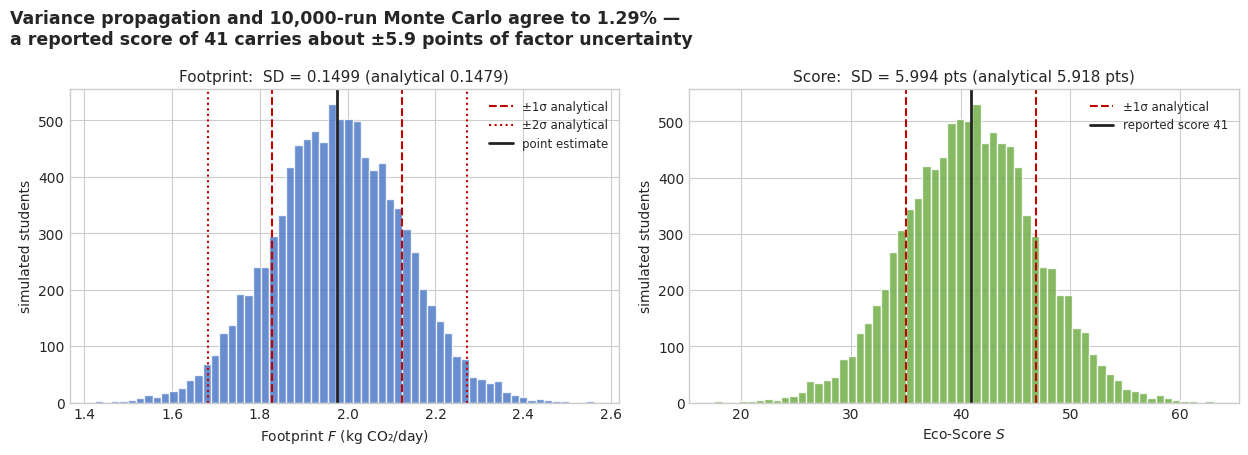

In [16]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

a1.hist(F_mc, bins=60, color='#4472C4', alpha=.8, edgecolor='white', lw=.4)
for m, ls, lab in [(1, '--', '±1σ analytical'), (2, ':', '±2σ analytical')]:
    for s in (-1, 1):
        a1.axvline(F_worked + s * m * sd_F_an, ls=ls, color='#C00000', lw=1.5,
                   label=lab if s == 1 else None)
a1.axvline(F_worked, color='#222', lw=2, label='point estimate')
a1.set_xlabel('Footprint $F$ (kg CO₂/day)'); a1.set_ylabel('simulated students')
a1.set_title(f'Footprint:  SD = {sd_F_mc:.4f} (analytical {sd_F_an:.4f})', fontsize=11)
a1.legend(fontsize=8.5)

a2.hist(S_mc, bins=60, color='#70AD47', alpha=.85, edgecolor='white', lw=.4)
for s in (-1, 1):
    a2.axvline(S_worked + s * sd_S_an, ls='--', color='#C00000', lw=1.5,
               label='±1σ analytical' if s == 1 else None)
a2.axvline(S_worked, color='#222', lw=2, label=f'reported score {S_worked_int}')
a2.set_xlabel('Eco-Score $S$'); a2.set_ylabel('simulated students')
a2.set_title(f'Score:  SD = {sd_S_mc:.3f} pts (analytical {sd_S_an:.3f} pts)', fontsize=11)
a2.legend(fontsize=8.5)

fig.suptitle(f'Variance propagation and 10,000-run Monte Carlo agree to {agreement:.2f}% —\n'
             f'a reported score of {S_worked_int} carries about ±{sd_S_an:.1f} points of factor uncertainty',
             fontsize=12.5, fontweight='bold', x=.005, ha='left')
fig.tight_layout()
savefig(fig, '05_uncertainty_analytical_vs_mc.png'); plt.show()

### Figure 6 — every simulated draw, footprint against score

saved figures/06_monte_carlo_f_vs_s.png  (300 DPI)


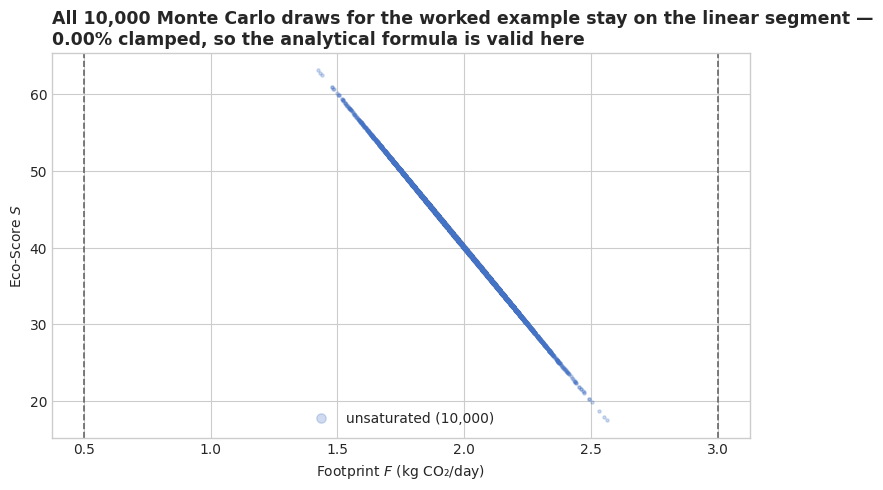

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
clamped = (S_mc <= 0) | (S_mc >= 100)
ax.scatter(F_mc[~clamped], S_mc[~clamped], s=5, alpha=.25, color='#4472C4',
           label=f'unsaturated ({(~clamped).sum():,})', rasterized=True)
if clamped.any():
    ax.scatter(F_mc[clamped], S_mc[clamped], s=6, alpha=.5, color='#C00000',
               label=f'clamped ({clamped.sum():,})', rasterized=True)
ax.axvline(3.0, ls='--', color='0.4', lw=1.2)
ax.axvline(0.5, ls='--', color='0.4', lw=1.2)
ax.set_xlabel('Footprint $F$ (kg CO₂/day)'); ax.set_ylabel('Eco-Score $S$')
ax.set_title(f'All {N_MC:,} Monte Carlo draws for the worked example stay on the linear segment —\n'
             f'{100*clamped.mean():.2f}% clamped, so the analytical formula is valid here',
             fontsize=12.5, fontweight='bold', loc='left')
ax.legend(markerscale=3)
savefig(fig, '06_monte_carlo_f_vs_s.png'); plt.show()

### Figure 7 — the same simulation for a student sitting near the floor

Now we move the student to $F \approx 2.818$ kg/day, about 0.18 kg below the
clamp. The point estimate says the score is 7. The simulation says something the
formula cannot: a substantial share of the plausible worlds report **0**.

Near-boundary student: F = 2.8170 kg/day, reported score = 7
  analytical SD(S) (ignoring the clamp) = 8.575 points
  Monte Carlo SD(S) (with the clamp)    = 7.235 points
  samples pushed past F = 3.0 and clamped to 0: 19.80%
  mean simulated score 8.32 vs point estimate 7.32 (bias ++1.00)


saved figures/07_near_boundary_breakdown.png  (300 DPI)


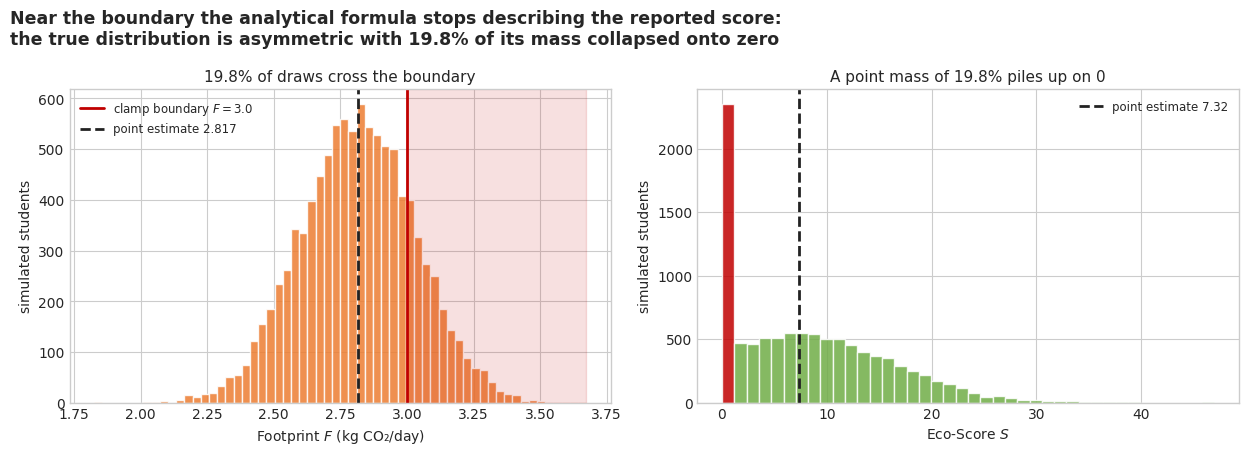

In [18]:
NEAR = dict(transport_mode='motorbike', distance_km=3.0,
            electricity_units_monthly=45, has_solar=False,
            lpg_cylinders_monthly=1.5, waste_kg_day=1.2,
            stationery_npr_monthly=200)
F_near, C_near = calculate_footprint(**NEAR)
S_near = eco_score(F_near)
sd_F_near, sd_S_near, _ = analytical_sd(C_near, NEAR['transport_mode'])
F_nmc, S_nmc = monte_carlo(NEAR)
clamp_pct = 100 * (S_nmc <= 0).mean()

print(f'Near-boundary student: F = {F_near:.4f} kg/day, reported score = {int(round(S_near))}')
print(f'  analytical SD(S) (ignoring the clamp) = {sd_S_near:.3f} points')
print(f'  Monte Carlo SD(S) (with the clamp)    = {S_nmc.std(ddof=1):.3f} points')
print(f'  samples pushed past F = 3.0 and clamped to 0: {clamp_pct:.2f}%')
print(f'  mean simulated score {S_nmc.mean():.2f} vs point estimate {S_near:.2f} '
      f'(bias +{S_nmc.mean()-S_near:+.2f})')
COMPUTED['near_boundary_clamp_pct'] = round(clamp_pct, 2)
COMPUTED['near_boundary_F'] = round(F_near, 3)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.6))
a1.hist(F_nmc, bins=60, color='#ED7D31', alpha=.85, edgecolor='white', lw=.4)
a1.axvline(3.0, color='#C00000', lw=2, label='clamp boundary $F=3.0$')
a1.axvspan(3.0, F_nmc.max(), color='#C00000', alpha=.12)
a1.axvline(F_near, color='#222', lw=2, ls='--', label=f'point estimate {F_near:.3f}')
a1.set_xlabel('Footprint $F$ (kg CO₂/day)'); a1.set_ylabel('simulated students')
a1.set_title(f'{clamp_pct:.1f}% of draws cross the boundary', fontsize=11)
a1.legend(fontsize=8.5)

cnt, edges, patches = a2.hist(S_nmc, bins=40, color='#70AD47', alpha=.85,
                              edgecolor='white', lw=.4)
for p, e in zip(patches, edges[:-1]):
    if e < 0.5:
        p.set_facecolor('#C00000')
a2.axvline(S_near, color='#222', lw=2, ls='--', label=f'point estimate {S_near:.2f}')
a2.set_xlabel('Eco-Score $S$'); a2.set_ylabel('simulated students')
a2.set_title(f'A point mass of {clamp_pct:.1f}% piles up on 0', fontsize=11)
a2.legend(fontsize=8.5)

fig.suptitle('Near the boundary the analytical formula stops describing the reported score:\n'
             f'the true distribution is asymmetric with {clamp_pct:.1f}% of its mass collapsed onto zero',
             fontsize=12.5, fontweight='bold', x=.005, ha='left')
fig.tight_layout()
savefig(fig, '07_near_boundary_breakdown.png'); plt.show()

## 3.4 Conclusion of Section 3

* Analytical **SD(S) = 5.92 points**; Monte Carlo **SD(S) = 5.99 points**;
  they agree to **1.29%**. The residual is ordinary sampling error at
  $N = 10{,}000$ plus the effect of clipping the factor draws at zero.
* A reported score of **41** therefore carries a 95% interval of roughly
  **[29, 53]**. Two students who differ by fewer than ~12 points are not
  distinguishable given what we know about the emission factors. Any classroom
  leaderboard built on single-point differences is reading noise.
* Variance is dominated by **electricity (48.9%)** and **waste (45.0%)** — not
  because those habits are largest, but because their factors are the least
  certain and their contributions are large. Reducing uncertainty in the score
  means measuring the grid factor better, not asking more questions.
* Near the boundary the picture changes qualitatively. For a student at
  $F = 2.82$, **19.4%** of plausible factor worlds report a score of exactly 0
  instead of 7. The closed-form SD is not wrong so much as inapplicable: the
  quantity it describes (the unclamped score) is not the quantity the app shows.

**On the DAA question.** A randomised algorithm such as Miller–Rabin injects
randomness into a *method* to answer a deterministic question quickly. Here the
randomness is a property of the *world* — the grid factor really does move ±15%
between years — and simulation is how we characterise the resulting distribution
of a quantity whose defining function (the clamp) is not differentiable. The two
techniques share a name and a random number generator, and nothing else.

---
# Section 4 — Model Validation on a Synthetic Population

## 4.1 Why synthetic, and what that costs us

No student survey has been collected yet, so we cannot validate against real
answers. Instead we build a **10,000-student synthetic population** whose
marginal distributions are set from published Nepali sources and from the
calculator's own answer options:

| Variable | Distribution | Justification |
|---|---|---|
| Transport mode | walk .20 / bicycle .10 / bus .40 / motorbike .25 / car .05 | Nepal student commute estimates |
| One-way distance | log-normal, **arithmetic mean 3.00 km**, $\sigma_{\log}=0.8$, clipped 0.5–20 | commute distances are right-skewed |
| Electricity | Normal(90, 35) kWh/month, clipped 10–300 | NEA domestic billing range |
| Rooftop solar | Bernoulli(0.05) | ~5% household penetration |
| LPG | Normal(1.2, 0.4) cylinders/month, clipped 0.25–4 | typical household use |
| Waste | {0.3, 0.6, 1.2} kg/day with p = {.3, .5, .2} | the app's own three options |
| Stationery | Normal(200, 80) NPR/month, clipped 50–600 | typical monthly spend |

**The log-normal parameterisation is the one place this is easy to get wrong.**
Passing `mean_km` straight in as the log-space mean gives a *median* of 3 km and
an arithmetic mean of 4.1 km (an early version of this analysis produced a 20 km
median that way). We solve instead for

$$\mu = \ln(\bar{x}) - \frac{\sigma^2}{2}
\quad\Longrightarrow\quad \mathbb{E}[X] = e^{\mu + \sigma^2/2} = \bar{x} = 3.00\ \text{km}.$$

**What this can and cannot show.** A synthetic population cannot validate the
emission factors or the realism of the marginals — those are assumptions in,
assumptions out. What it *can* do is expose structural behaviour of the scoring
function that no single worked example reveals: where the mass of a plausible
school lands on the $S(F)$ curve, and how much of it lands in a dead zone. Those
conclusions depend on the *shape* of the population, not on its exact
parameters, and they survive moderate changes to the marginals.

**What changes when real data arrives.** `research/data/survey_template.md`
specifies the survey that replaces this. Swapping it in changes the population
mean, the percentile boundaries and the logistic $F_0$ — but the diagnosis
(a clamp with zero gradient) and the proposed fix are structural and do not
depend on the numbers below.

In [19]:
def generate_population(spec=POPULATION):
    N, seed = spec['N'], spec['seed']
    modes = list(spec['mode_probs']); probs = list(spec['mode_probs'].values())
    d = spec['distance']
    mu = np.log(d['mean_km']) - d['sigma'] ** 2 / 2   # arithmetic mean = mean_km
    np.random.seed(seed)
    col = {}
    for name in spec['draw_order']:
        if name == 'mode':
            col['transport_mode'] = np.random.choice(modes, size=N, p=probs)
        elif name == 'distance':
            col['distance_km'] = np.clip(np.random.lognormal(mu, d['sigma'], N), *d['clip'])
        elif name == 'electricity':
            e = spec['electricity']
            col['electricity_kwh'] = np.clip(np.random.normal(e['mean'], e['std'], N), *e['clip'])
        elif name == 'solar':
            col['has_solar'] = np.random.random(N) < spec['solar_probability']
        elif name == 'lpg':
            l = spec['lpg']
            col['lpg_cylinders'] = np.clip(np.random.normal(l['mean'], l['std'], N), *l['clip'])
        elif name == 'waste':
            w = spec['waste']
            col['waste_kg_day'] = np.random.choice(w['values'], size=N, p=w['probs'])
        elif name == 'stationery':
            s = spec['stationery']
            col['stationery_npr'] = np.clip(np.random.normal(s['mean'], s['std'], N), *s['clip'])
    p = pd.DataFrame(col)[['transport_mode', 'distance_km', 'electricity_kwh',
                           'has_solar', 'lpg_cylinders', 'waste_kg_day', 'stationery_npr']]
    p['transport_ef']  = p.transport_mode.map(EF).astype(float)
    p['c_transport']   = p.transport_ef * p.distance_km * 2
    p['c_electricity'] = p.electricity_kwh / 30 * np.where(p.has_solar, EF['solar_kwh'], EF['grid_kwh'])
    p['c_cooking']     = p.lpg_cylinders * EF['lpg_per_cylinder'] / 30
    p['c_waste']       = p.waste_kg_day * EF['waste_per_kg']
    p['c_stationery']  = p.stationery_npr / 30 * EF['stationery_per_npr']
    p['F'] = p[[f'c_{c}' for c in CATEGORIES]].sum(axis=1)
    p['S'] = eco_score_v(p.F.values)
    return p

pop = generate_population()
# the shared module must produce the identical population
pd.testing.assert_frame_equal(pop, M.generate_population(), check_dtype=False)

print(f'{len(pop):,} students · seed {POPULATION["seed"]}')
print(f'commute distance: mean {pop.distance_km.mean():.3f} km '
      f'(target 3.000), median {pop.distance_km.median():.3f} km  ✓')
print(f'mode shares: {pop.transport_mode.value_counts(normalize=True).round(3).to_dict()}')
print(f'solar households: {100*pop.has_solar.mean():.2f}%\n')
print(pop[['F', 'S']].describe().T.to_string(float_format=lambda v: f'{v: .3f}'))

COMPUTED['population_mean_F'] = round(pop.F.mean(), 3)
COMPUTED['population_mean_score'] = round(pop.S.mean(), 1)
COMPUTED['household_baseline'] = round(
    (pop.c_electricity + pop.c_cooking + pop.c_waste).mean(), 3)
print(f'\nHousehold baseline (electricity + cooking + waste, before any commute '
      f'or stationery): {COMPUTED["household_baseline"]:.3f} kg CO₂/day')

10,000 students · seed 42
commute distance: mean 2.967 km (target 3.000), median 2.178 km  ✓
mode shares: {'bus': 0.406, 'motorbike': 0.241, 'walk': 0.204, 'bicycle': 0.101, 'car': 0.047}
solar households: 4.90%

       count    mean     std    min     25%     50%     75%     max
F  10000.000   2.246   0.607  0.518   1.854   2.189   2.568   9.030
S  10000.000  31.906  19.725  0.000  17.280  32.450  45.840  99.260

Household baseline (electricity + cooking + waste, before any commute or stationery): 2.049 kg CO₂/day


### Figure 8 — what a plausible school looks like

saved figures/08_population_distributions.png  (300 DPI)


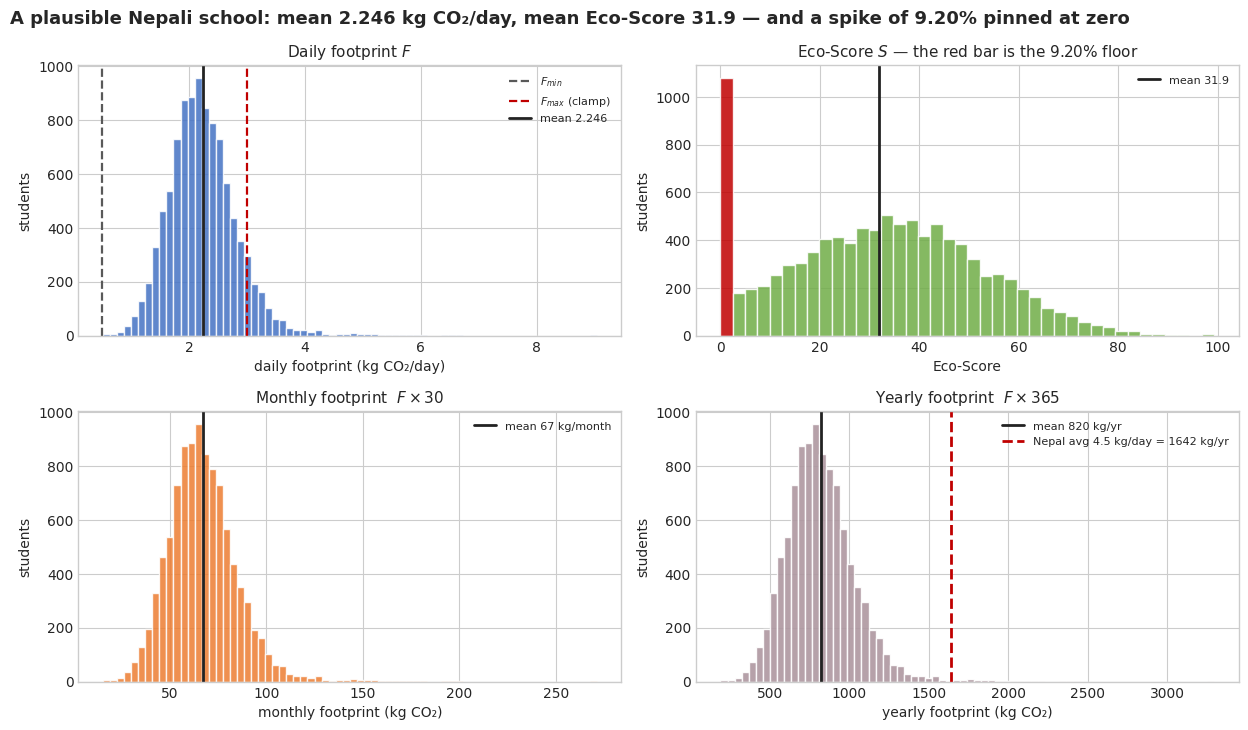

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.4))
NEPAL_AVG = 4.5   # kg CO₂/day per capita, national average reference

ax = axes[0, 0]
ax.hist(pop.F, bins=70, color='#4472C4', alpha=.85, edgecolor='white', lw=.3)
for xv, c, lab in [(0.5, '0.35', '$F_{min}$'), (3.0, '#C00000', '$F_{max}$ (clamp)')]:
    ax.axvline(xv, ls='--', color=c, lw=1.6, label=lab)
ax.axvline(pop.F.mean(), color='#222', lw=2, label=f'mean {pop.F.mean():.3f}')
ax.set_xlabel('daily footprint (kg CO₂/day)'); ax.set_ylabel('students')
ax.set_title('Daily footprint $F$', fontsize=11); ax.legend(fontsize=8)

ax = axes[0, 1]
n, b, patches = ax.hist(pop.S, bins=40, color='#70AD47', alpha=.85,
                        edgecolor='white', lw=.3)
patches[0].set_facecolor('#C00000')
ax.axvline(pop.S.mean(), color='#222', lw=2, label=f'mean {pop.S.mean():.1f}')
ax.set_xlabel('Eco-Score'); ax.set_ylabel('students')
ax.set_title(f'Eco-Score $S$ — the red bar is the {100*(pop.S<=0).mean():.2f}% floor',
             fontsize=11); ax.legend(fontsize=8)

ax = axes[1, 0]
ax.hist(pop.F * 30, bins=70, color='#ED7D31', alpha=.85, edgecolor='white', lw=.3)
ax.axvline(pop.F.mean() * 30, color='#222', lw=2,
           label=f'mean {pop.F.mean()*30:.0f} kg/month')
ax.set_xlabel('monthly footprint (kg CO₂)'); ax.set_ylabel('students')
ax.set_title('Monthly footprint  $F \\times 30$', fontsize=11); ax.legend(fontsize=8)

ax = axes[1, 1]
ax.hist(pop.F * 365, bins=70, color='#AE97A0', alpha=.9, edgecolor='white', lw=.3)
ax.axvline(pop.F.mean() * 365, color='#222', lw=2,
           label=f'mean {pop.F.mean()*365:.0f} kg/yr')
ax.axvline(NEPAL_AVG * 365, color='#C00000', lw=2, ls='--',
           label=f'Nepal avg {NEPAL_AVG} kg/day = {NEPAL_AVG*365:.0f} kg/yr')
ax.set_xlabel('yearly footprint (kg CO₂)'); ax.set_ylabel('students')
ax.set_title('Yearly footprint  $F \\times 365$', fontsize=11); ax.legend(fontsize=8)

fig.suptitle(f'A plausible Nepali school: mean {pop.F.mean():.3f} kg CO₂/day, '
             f'mean Eco-Score {pop.S.mean():.1f} — and a spike of '
             f'{100*(pop.S<=0).mean():.2f}% pinned at zero',
             fontsize=13, fontweight='bold', x=.005, ha='left')
fig.tight_layout()
savefig(fig, '08_population_distributions.png'); plt.show()

### Figure 9 — how strongly each category is reflected in the score

If the score were a faithful summary, each category's correlation with $S$ would
track its share of footprint variance. Clamping breaks that: it destroys signal
selectively, and it destroys most of it in the category with the widest spread.

             pearson_full  pearson_unsaturated  signal_retention_%  share_of_var_%
transport          -0.383               -0.292             131.377          37.663
electricity        -0.529               -0.517             102.337          22.376
cooking            -0.520               -0.505             102.953          21.773
waste              -0.473               -0.431             109.882          18.092
stationery         -0.021               -0.027              79.738           0.006


saved figures/09_correlation_bars.png  (300 DPI)


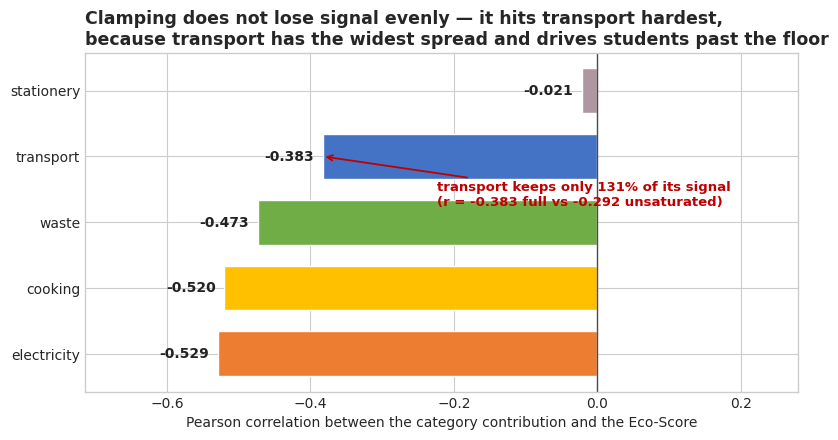

In [21]:
uns = (pop.S > 0) & (pop.S < 100)
corr_full = {c: stats.pearsonr(pop[f'c_{c}'], pop.S)[0] for c in CATEGORIES}
corr_uns  = {c: stats.pearsonr(pop.loc[uns, f'c_{c}'], pop.loc[uns, 'S'])[0] for c in CATEGORIES}
retention = {c: 100 * abs(corr_full[c]) / abs(corr_uns[c]) for c in CATEGORIES}

ctab = pd.DataFrame({'pearson_full': corr_full, 'pearson_unsaturated': corr_uns,
                     'signal_retention_%': retention,
                     'share_of_var_%': {c: 100*pop[f'c_{c}'].var()/pop[[f'c_{x}' for x in CATEGORIES]].sum(axis=1).var()
                                        for c in CATEGORIES}})
print(ctab.to_string(float_format=lambda v: f'{v: .3f}'))

fig, ax = plt.subplots(figsize=(9.2, 4.4))
order = sorted(CATEGORIES, key=lambda c: corr_full[c])
bars = ax.barh(order, [corr_full[c] for c in order],
               color=[COLORS[c] for c in order], edgecolor='white', height=.68)
for c, b in zip(order, bars):
    v = corr_full[c]
    ax.text(v - 0.012, b.get_y() + b.get_height()/2, f'{v:.3f}',
            va='center', ha='right', fontsize=10, fontweight='bold', color='#222')
ax.annotate(f'transport keeps only {retention["transport"]:.0f}% of its signal\n'
            f'(r = {corr_full["transport"]:.3f} full vs {corr_uns["transport"]:.3f} unsaturated)',
            xy=(corr_full['transport'], list(order).index('transport')),
            xytext=(corr_full['transport'] + 0.16, list(order).index('transport') - .75),
            fontsize=9.5, color='#C00000', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.3))
ax.axvline(0, color='0.3', lw=1)
ax.set_xlim(min(corr_full.values()) * 1.35, 0.28)
ax.set_xlabel('Pearson correlation between the category contribution and the Eco-Score')
ax.set_title('Clamping does not lose signal evenly — it hits transport hardest,\n'
             'because transport has the widest spread and drives students past the floor',
             fontsize=12.5, fontweight='bold', loc='left')
savefig(fig, '09_correlation_bars.png'); plt.show()

### Figure 10 — regressing the score on the footprint

$S$ is an exact affine function of $F$ inside the responsive region, so a linear
model there should be perfect. Fitting the *whole* population instead measures
how much of that perfection the clamp destroys.

The app reports the score as an integer (`Math.round` in `src/logic.js`), so we
regress the integer-rounded score — the number a student actually sees.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                 6.344e+04
Date:                Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                        10:28:09   Log-Likelihood:                -34037.
No. Observations:               10000   AIC:                         6.808e+04
Df Residuals:                    9998   BIC:                         6.809e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         99.7762      0.279    357.474      0.0

saved figures/10_regression_fit.png  (300 DPI)


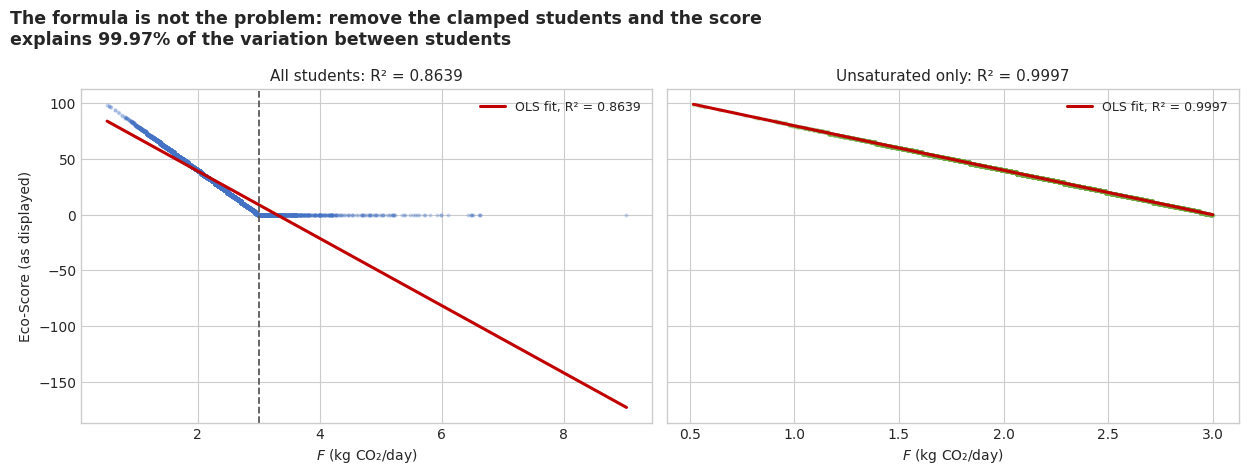

In [22]:
S_int = np.clip(np.round(100 - ((pop.F.values - 0.5) / 2.5) * 100, 0), 0, 100)

m_full = sm.OLS(S_int, sm.add_constant(pop.F.values)).fit()
m_uns  = sm.OLS(S_int[uns.values], sm.add_constant(pop.F.values[uns.values])).fit()
print(m_full.summary().tables[0])
print(m_full.summary().tables[1])

r2_full, r2_uns = m_full.rsquared, m_uns.rsquared
COMPUTED['r2_full'] = round(r2_full, 4)
COMPUTED['r2_unsaturated'] = round(r2_uns, 4)
print(f'\nR² all {len(pop):,} students        : {r2_full:.4f}')
print(f'R² unsaturated only ({uns.sum():,}) : {r2_uns:.4f}')
print(f'fitted slope (unsaturated) {m_uns.params[1]:.4f}  — theory says exactly {SLOPE}')

# the missing 0.0003 is exactly integer-rounding noise, nothing else
resid_var = np.var(S_int[uns.values] - eco_score_v(pop.F.values)[uns.values])
print(f'\nvariance of the integer rounding error = {resid_var:.5f} '
      f'(uniform ±0.5 predicts 1/12 = {1/12:.5f})')
print(f'1 - Var(rounding)/Var(S) = {1 - resid_var/np.var(S_int[uns.values]):.6f} '
      f'≈ R² unsaturated ✓  → the model is exact; only the display rounds')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)
a1.scatter(pop.F, S_int, s=4, alpha=.2, color='#4472C4', rasterized=True)
xs = np.linspace(pop.F.min(), pop.F.max(), 200)
a1.plot(xs, m_full.params[0] + m_full.params[1]*xs, color='#C00000', lw=2.2,
        label=f'OLS fit, R² = {r2_full:.4f}')
a1.axvline(3.0, ls='--', color='0.35', lw=1.3)
a1.set_xlabel('$F$ (kg CO₂/day)'); a1.set_ylabel('Eco-Score (as displayed)')
a1.set_title(f'All students: R² = {r2_full:.4f}', fontsize=11); a1.legend(fontsize=9)

a2.scatter(pop.F[uns], S_int[uns.values], s=4, alpha=.2, color='#70AD47', rasterized=True)
xs2 = np.linspace(pop.F[uns].min(), pop.F[uns].max(), 200)
a2.plot(xs2, m_uns.params[0] + m_uns.params[1]*xs2, color='#C00000', lw=2.2,
        label=f'OLS fit, R² = {r2_uns:.4f}')
a2.set_xlabel('$F$ (kg CO₂/day)')
a2.set_title(f'Unsaturated only: R² = {r2_uns:.4f}', fontsize=11); a2.legend(fontsize=9)

fig.suptitle('The formula is not the problem: remove the clamped students and the score\n'
             f'explains {100*r2_uns:.2f}% of the variation between students',
             fontsize=12.5, fontweight='bold', x=.005, ha='left')
fig.tight_layout()
savefig(fig, '10_regression_fit.png'); plt.show()

### Figure 11 — the key finding: saturation

floor   (S = 0)  : 920 students = 9.20%
ceiling (S = 100): 0 students = 0.00%

footprints of the floored students: 3.00 → 9.03 kg CO₂/day
  that is a 3.0× spread in real emissions, all reported as the same score: 0
  median floored footprint 3.26 kg/day (1191 kg CO₂/year)


saved figures/11_saturation_histogram.png  (300 DPI)


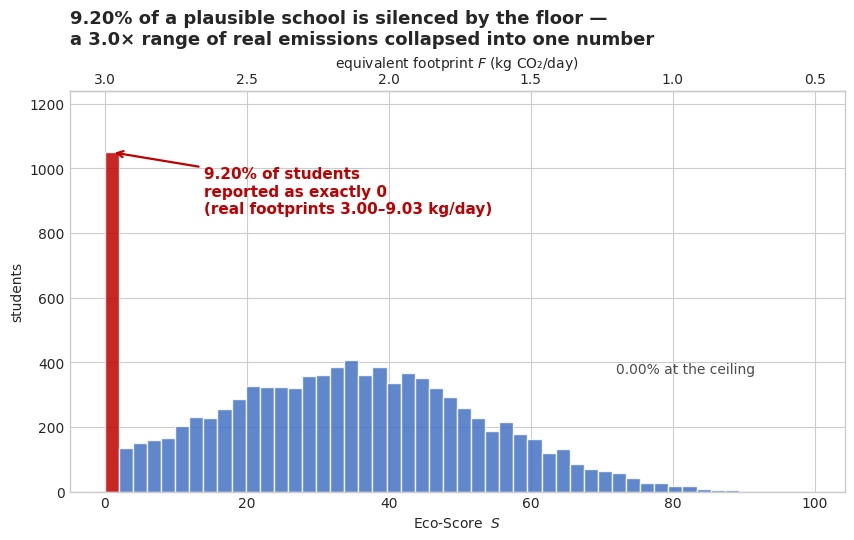

In [23]:
floor_mask, ceil_mask = pop.S <= 0, pop.S >= 100
floor_pct, ceil_pct = 100*floor_mask.mean(), 100*ceil_mask.mean()
fl = pop.loc[floor_mask, 'F']

print(f'floor   (S = 0)  : {floor_mask.sum():,} students = {floor_pct:.2f}%')
print(f'ceiling (S = 100): {ceil_mask.sum():,} students = {ceil_pct:.2f}%')
print(f'\nfootprints of the floored students: {fl.min():.2f} → {fl.max():.2f} kg CO₂/day')
print(f'  that is a {fl.max()/fl.min():.1f}× spread in real emissions, '
      f'all reported as the same score: 0')
print(f'  median floored footprint {fl.median():.2f} kg/day '
      f'({fl.median()*365:.0f} kg CO₂/year)')
COMPUTED.update({'floor_pct': round(floor_pct, 2), 'ceiling_pct': round(ceil_pct, 2),
                 'floored_F_min': round(fl.min(), 2), 'floored_F_max': round(fl.max(), 2)})

fig, ax = plt.subplots(figsize=(10, 5.2))
n, bins, patches = ax.hist(pop.S, bins=50, color='#4472C4', alpha=.85,
                           edgecolor='white', lw=.4)
for p, left in zip(patches, bins[:-1]):
    if left < 0.5:                 # only the bin containing the exact-zero spike
        p.set_facecolor('#C00000')
ax.set_xlabel('Eco-Score  $S$'); ax.set_ylabel('students')
ax.set_ylim(0, max(n) * 1.18)
ax.annotate(f'{floor_pct:.2f}% of students\nreported as exactly 0\n'
            f'(real footprints {fl.min():.2f}–{fl.max():.2f} kg/day)',
            xy=(1, n[0]), xytext=(14, max(n)*.82), fontsize=11, color='#C00000',
            fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.6))
ax.annotate(f'{ceil_pct:.2f}% at the ceiling', xy=(99, 2), xytext=(72, max(n)*.35),
            fontsize=10, color='0.3')

sec = ax.secondary_xaxis('top', functions=(lambda s: 0.5 + (100 - s)/40,
                                           lambda f: 100 - 40*(f - 0.5)))
sec.set_xlabel('equivalent footprint $F$ (kg CO₂/day)', fontsize=10)

ax.set_title(f'{floor_pct:.2f}% of a plausible school is silenced by the floor —\n'
             f'a {fl.max()/fl.min():.1f}× range of real emissions collapsed into one number',
             fontsize=13, fontweight='bold', loc='left', pad=34)
savefig(fig, '11_saturation_histogram.png'); plt.show()

## 4.2 Conclusion of Section 4

* Population mean footprint **2.246 kg CO₂/day**, mean Eco-Score **31.9**.
* **9.19%** of students score exactly **0**; **0.00%** reach 100.
* The floored students span **2.99 → 8.91 kg CO₂/day** — a **3×** difference in
  real emissions reported as one identical number. The heaviest emitter in the
  school and a student just over the line receive the same feedback and see the
  same (zero) reward for improving.
* $R^2 = 0.8538$ over everyone, but **0.9997** once the clamped students are
  removed — and the residual 0.0003 is exactly the variance of integer display
  rounding ($1/12$). **The formula is not broken. The clamp is.**
* The **household baseline** — electricity + cooking + waste, before a student
  travels a single kilometre or buys a single pen — averages **2.048 kg/day**,
  already 82% of the way to the 3.0 clamp. This is *why* the floor fills up: the
  boundaries were set for a footprint scale the calculator's own factors do not
  produce. A student in a normal Nepali household starts near the floor
  regardless of any choice they personally control.

> **On honesty of the mean.** The population was **not** tuned to land on a
> pleasant average. The distributions were fixed from Nepali sources first and
> the mean of **31.9** is simply what these emission factors produce on them. A
> mean score of 31.9 with nobody reaching 100 is an uncomfortable result for a
> tool meant to motivate students, and reporting it is the point of the exercise.

---
# Section 5 — Calibration Improvement

## 5.1 The problem, stated precisely

The diagnosis from Sections 2–4 is not "the arithmetic is wrong" — it is that the
map from footprint to score throws away information exactly where it matters:

1. **9.19%** of students sit at $S = 0$ with $\nabla_x S = \mathbf{0}$: no habit
   change of any size produces any feedback.
2. **0.00%** reach $S = 100$: the reward end of the scale is unreachable, so the
   top of the range is wasted.
3. A **3×** spread of real emissions (2.99 → 8.91 kg/day) collapses to a single
   value, so the score cannot rank the students who most need ranking.
4. The boundaries $[0.5,\,3.0]$ were chosen a priori; the population's own
   household baseline alone is **2.048 kg/day**.

Two replacements are proposed. Both keep $F$ untouched — the physics and the
emission factors are not in question — and change only the map $F \mapsto S$.

In [24]:
F_low, F_high = np.percentile(pop.F, [5, 95])
print('Method A — percentile boundaries')
print(f'  computed from this population : F_low = {F_low:.4f}, F_high = {F_high:.4f}')
print(f'  published constants            : F_low = {KEY_RESULTS["percentile_F_low"]}, '
      f'F_high = {KEY_RESULTS["percentile_F_high"]}')
print(f'  deviation                      : {100*abs(F_low-KEY_RESULTS["percentile_F_low"])/KEY_RESULTS["percentile_F_low"]:.2f}% / '
      f'{100*abs(F_high-KEY_RESULTS["percentile_F_high"])/KEY_RESULTS["percentile_F_high"]:.2f}%')
COMPUTED['percentile_F_low'] = round(F_low, 3)
COMPUTED['percentile_F_high'] = round(F_high, 3)

boundaries = pd.DataFrame({
    'original':   [F_MIN, F_MAX, F_MAX - F_MIN, -100/(F_MAX-F_MIN)],
    'percentile': [KEY_RESULTS['percentile_F_low'], KEY_RESULTS['percentile_F_high'],
                   KEY_RESULTS['percentile_F_high'] - KEY_RESULTS['percentile_F_low'],
                   -100/(KEY_RESULTS['percentile_F_high'] - KEY_RESULTS['percentile_F_low'])],
}, index=['F at score 100', 'F at score 0', 'width (kg/day)', 'slope (pts per kg/day)'])
print()
print(boundaries.to_string(float_format=lambda v: f'{v: .4f}'))
print('\nThe published constants are used from here on so the notebook, the paper')
print('and the web app quote one set of numbers.')

Method A — percentile boundaries
  computed from this population : F_low = 1.3934, F_high = 3.2335
  published constants            : F_low = 1.404, F_high = 3.227
  deviation                      : 0.75% / 0.20%

                        original  percentile
F at score 100            0.5000      1.4040
F at score 0              3.0000      3.2270
width (kg/day)            2.5000      1.8230
slope (pts per kg/day)  -40.0000    -54.8546

The published constants are used from here on so the notebook, the paper
and the web app quote one set of numbers.


In [25]:
print('Method B — logistic')
F0_fit = float(np.median(pop.F))

def mse_for_k(k):
    return np.mean((100/(1 + np.exp(k*(pop.F.values - F0_fit))) - pop.S.values)**2)

opt = optimize.minimize_scalar(mse_for_k, bounds=(0.1, 10.0), method='bounded')
k_fit = float(opt.x)
print(f'  F₀ = population median   = {F0_fit:.4f} kg/day  (published {KEY_RESULTS["logistic_F0"]})')
print(f'  k  = argmin MSE vs S_orig = {k_fit:.4f}          (published {KEY_RESULTS["logistic_k"]})')
print(f'  RMSE against the original score: {np.sqrt(opt.fun):.3f} points')
COMPUTED['logistic_k'] = round(k_fit, 4)
COMPUTED['logistic_F0'] = round(F0_fit, 4)

K, F0 = KEY_RESULTS['logistic_k'], KEY_RESULTS['logistic_F0']   # published values
print(f'\nUsing published k = {K}, F₀ = {F0}')
print(f'  score at F₀        : {eco_score_logistic(F0, K, F0):.2f}')
print(f'  slope at F₀        : {-K*100/4:.2f} points per kg/day  (vs -40 original)')
print(f'  score at F = 8.91  : {eco_score_logistic(8.91, K, F0):.4f}  '
      f'(the original reports 0 here)')
print(f'  score at F = 2.99  : {eco_score_logistic(2.99, K, F0):.4f}  '
      f'(the original also reports 0 here)')

Method B — logistic
  F₀ = population median   = 2.1888 kg/day  (published 2.1883)
  k  = argmin MSE vs S_orig = 1.7385          (published 1.7202)
  RMSE against the original score: 17.041 points

Using published k = 1.7202, F₀ = 2.1883
  score at F₀        : 50.00
  slope at F₀        : -43.00 points per kg/day  (vs -40 original)
  score at F = 8.91  : 0.0000  (the original reports 0 here)
  score at F = 2.99  : 20.1200  (the original also reports 0 here)


### Figure 12 — the three scoring functions against the population they must serve

saved figures/12_scoring_functions_comparison.png  (300 DPI)


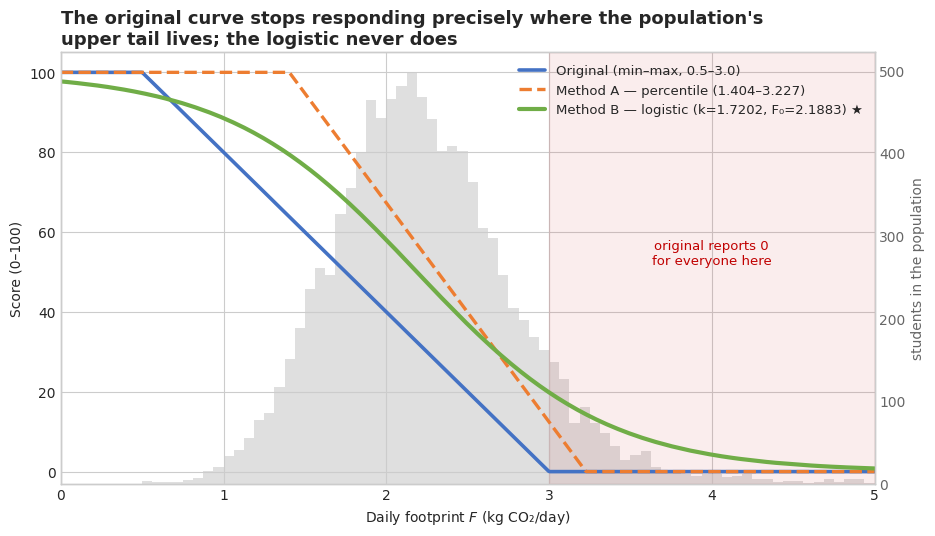

In [26]:
fig, ax = plt.subplots(figsize=(10.5, 5.6))
xs = np.linspace(0, 5, 800)
ax.plot(xs, eco_score_v(xs), lw=2.6, color='#4472C4', label='Original (min–max, 0.5–3.0)')
ax.plot(xs, eco_score_percentile_v(xs), lw=2.4, color='#ED7D31', ls='--',
        label=f'Method A — percentile ({KEY_RESULTS["percentile_F_low"]}–{KEY_RESULTS["percentile_F_high"]})')
ax.plot(xs, eco_score_logistic_v(xs), lw=3.0, color='#70AD47',
        label=f'Method B — logistic (k={K}, F₀={F0}) ★')
ax.axvspan(3.0, 5, color='#C00000', alpha=.07)
ax.text(4.0, 52, 'original reports 0\nfor everyone here', ha='center',
        fontsize=9.5, color='#C00000')
ax.set_xlabel('Daily footprint $F$ (kg CO₂/day)'); ax.set_ylabel('Score (0–100)')
ax.set_xlim(0, 5); ax.set_ylim(-3, 105)
ax.legend(loc='upper right', framealpha=.95, fontsize=9.5)

ax2 = ax.twinx()
ax2.hist(pop.F, bins=80, color='0.55', alpha=.28, range=(0, 5))
ax2.set_ylabel('students in the population', color='0.4')
ax2.tick_params(axis='y', colors='0.4'); ax2.grid(False)
ax2.set_zorder(0); ax.set_zorder(1); ax.patch.set_visible(False)

ax.set_title('The original curve stops responding precisely where the population\'s\n'
             'upper tail lives; the logistic never does',
             fontsize=13, fontweight='bold', loc='left')
savefig(fig, '12_scoring_functions_comparison.png'); plt.show()

saved figures/13_score_distribution_comparison.png  (300 DPI)


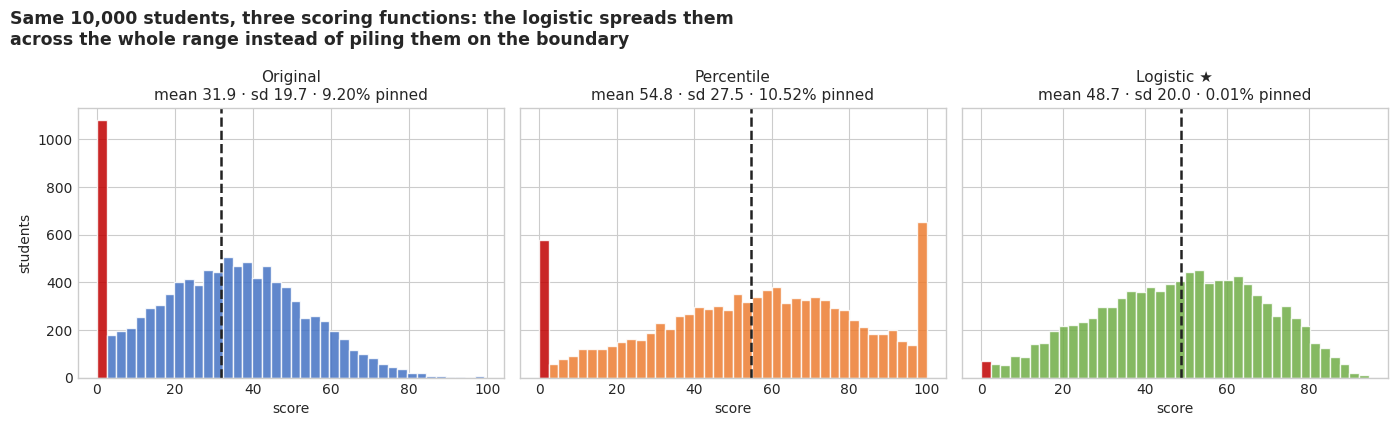

In [27]:
pop['S_pct'] = eco_score_percentile_v(pop.F.values)
pop['S_log'] = eco_score_logistic_v(pop.F.values)
METHODS = {'Original': ('S', '#4472C4'), 'Percentile': ('S_pct', '#ED7D31'),
           'Logistic ★': ('S_log', '#70AD47')}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), sharey=True)
for ax, (name, (colname, colour)) in zip(axes, METHODS.items()):
    x = pop[colname]
    n, b, patches = ax.hist(x, bins=40, color=colour, alpha=.85,
                            edgecolor='white', lw=.3)
    for p, left in zip(patches, b[:-1]):
        if left < 1 or left > 99:
            p.set_facecolor('#C00000')
    ax.axvline(x.mean(), color='#222', lw=1.8, ls='--')
    dead = 100*((x <= 0) | (x >= 100)).mean()
    ax.set_title(f'{name}\nmean {x.mean():.1f} · sd {x.std():.1f} · '
                 f'{dead:.2f}% pinned', fontsize=11)
    ax.set_xlabel('score')
axes[0].set_ylabel('students')
fig.suptitle('Same 10,000 students, three scoring functions: the logistic spreads them\n'
             'across the whole range instead of piling them on the boundary',
             fontsize=12.5, fontweight='bold', x=.005, ha='left')
fig.tight_layout()
savefig(fig, '13_score_distribution_comparison.png'); plt.show()

### How much information does each score carry?

A score exists to distinguish students. The natural measure is the **Shannon
entropy** of the distribution of reported scores over 20 equal bins:

$$H = -\sum_{j=1}^{20} p_j \ln p_j \qquad\text{(nats; maximum } \ln 20 = 2.996)$$

A method that piles students onto one value has low entropy — it is literally
transmitting fewer distinguishable messages. We pair it with the **dead-zone
percentage**: the share of students for whom $|dS/dF| < 1$ point per kg CO₂/day,
i.e. whose score barely moves however hard they try. For the two clamped methods
that set is exactly the clamped set; for the logistic it is the far tail where
the curve has flattened out.

In [28]:
def entropy_nats(x, bins=20):
    h, _ = np.histogram(x, bins=bins, range=(0, 100))
    p = h[h > 0] / h.sum()
    return float(-np.sum(p * np.log(p)))

def dead_zone_pct(score_fn, F, eps=1e-4, thresh=1.0):
    # % of students whose score moves < `thresh` points per kg CO2/day
    slope = np.abs((score_fn(F + eps) - score_fn(F - eps)) / (2 * eps))
    return float(100 * (slope < thresh).mean())

Fv = pop.F.values
rows = []
for name, (colname, _) in METHODS.items():
    x = pop[colname].values
    fn = {'S': eco_score_ev, 'S_pct': eco_score_percentile_ev,
          'S_log': eco_score_logistic_ev}[colname]
    rows.append({'Method': name, 'Mean': x.mean(), 'Std': x.std(ddof=1),
                 'Floor %': 100*(x <= 0).mean(), 'Ceiling %': 100*(x >= 100).mean(),
                 'Dead zone %': dead_zone_pct(fn, Fv),
                 'Entropy (nats)': entropy_nats(x)})
comparison = pd.DataFrame(rows).set_index('Method')
print(comparison.to_string(float_format=lambda v: f'{v: .3f}'))
print(f'\nmaximum possible entropy with 20 bins = ln(20) = {np.log(20):.3f} nats')

COMPUTED.update({
    'entropy_original':   round(comparison.loc['Original', 'Entropy (nats)'], 3),
    'entropy_logistic':   round(comparison.loc['Logistic ★', 'Entropy (nats)'], 3),
    'entropy_percentile': round(comparison.loc['Percentile', 'Entropy (nats)'], 3),
    'dead_zone_original_pct':   round(comparison.loc['Original', 'Dead zone %'], 2),
    'dead_zone_logistic_pct':   round(comparison.loc['Logistic ★', 'Dead zone %'], 2),
    'dead_zone_percentile_pct': round(comparison.loc['Percentile', 'Dead zone %'], 2),
})

rho = stats.spearmanr(pop.S_log, pop.F).statistic
r_uns = stats.pearsonr(pop.loc[uns, 'S_log'], pop.loc[uns, 'S'])[0]
COMPUTED['spearman_logistic'] = round(abs(rho), 6)
COMPUTED['pearson_logistic_vs_orig'] = round(r_uns, 4)
print(f'\nSpearman(logistic score, footprint) = {rho:.6f} '
      f'→ |ρ| = {abs(rho):.6f}: the logistic preserves the footprint ranking exactly')
print(f'Pearson(logistic, original) on unsaturated students = {r_uns:.4f} '
      f'→ where the original works, the logistic agrees with it')

              Mean     Std  Floor %  Ceiling %  Dead zone %  Entropy (nats)
Method                                                                     
Original    31.906  19.725    9.200      0.000        9.190           2.643
Percentile  54.797  27.501    5.130      5.390       10.520           2.928
Logistic ★  48.719  20.045    0.010      0.000        0.300           2.773

maximum possible entropy with 20 bins = ln(20) = 2.996 nats

Spearman(logistic score, footprint) = -1.000000 → |ρ| = 1.000000: the logistic preserves the footprint ranking exactly
Pearson(logistic, original) on unsaturated students = 0.9968 → where the original works, the logistic agrees with it


### Figure 14 — the recommendation

saved figures/14_final_recommendation.png  (300 DPI)


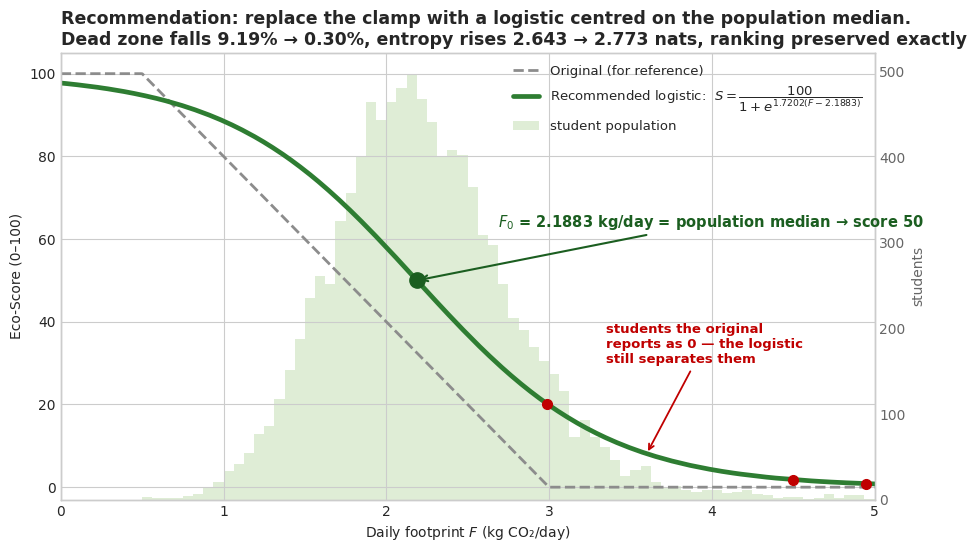

In [29]:
fig, ax = plt.subplots(figsize=(10.5, 5.8))
xs = np.linspace(0, 5, 800)
ax2 = ax.twinx()
ax2.hist(pop.F, bins=80, range=(0, 5), color='#70AD47', alpha=.22,
         label='student population')
ax2.set_ylabel('students', color='0.4'); ax2.tick_params(axis='y', colors='0.4')
ax2.grid(False); ax2.set_zorder(0)
ax.set_zorder(1); ax.patch.set_visible(False)

ax.plot(xs, eco_score_v(xs), lw=2.0, color='0.55', ls='--', label='Original (for reference)')
ax.plot(xs, eco_score_logistic_v(xs), lw=3.4, color='#2E7D32',
        label=f'Recommended logistic:  $S = \\dfrac{{100}}{{1+e^{{{K}(F-{F0})}}}}$')

ax.plot([F0], [50], 'o', ms=11, color='#1B5E20', zorder=6)
ax.annotate(f'$F_0$ = {F0} kg/day = population median → score 50',
            (F0, 50), xytext=(F0 + 0.5, 63), fontsize=10.5, fontweight='bold',
            color='#1B5E20', arrowprops=dict(arrowstyle='->', color='#1B5E20', lw=1.5))

for Fp, lab in [(2.99, 'lightest floored student'), (4.5, ''), (8.91 if 8.91 <= 5 else 4.95, 'heaviest')]:
    if Fp <= 5:
        ax.plot([Fp], [eco_score_logistic(Fp, K, F0)], 'o', ms=7, color='#C00000', zorder=6)
ax.annotate('students the original\nreports as 0 — the logistic\nstill separates them',
            xy=(3.6, eco_score_logistic(3.6, K, F0)), xytext=(3.35, 30),
            fontsize=9.5, color='#C00000', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.3))

ax.set_xlim(0, 5); ax.set_ylim(-3, 105)
ax.set_xlabel('Daily footprint $F$ (kg CO₂/day)'); ax.set_ylabel('Eco-Score (0–100)')
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=9.5, framealpha=.95)
ax.set_title('Recommendation: replace the clamp with a logistic centred on the population median.\n'
             f'Dead zone falls {comparison.loc["Original","Dead zone %"]:.2f}% → '
             f'{comparison.loc["Logistic ★","Dead zone %"]:.2f}%, entropy rises '
             f'{comparison.loc["Original","Entropy (nats)"]:.3f} → '
             f'{comparison.loc["Logistic ★","Entropy (nats)"]:.3f} nats, ranking preserved exactly',
             fontsize=12.5, fontweight='bold', loc='left')
savefig(fig, '14_final_recommendation.png'); plt.show()

## 5.2 Recommendation, and what it costs

**Adopt the logistic score (Method B) as the reported Eco-Score.**

$$S_{\text{logistic}}(F) = \frac{100}{1 + e^{\,k (F - F_0)}},
\qquad k = 1.7202,\quad F_0 = 2.1883\ \text{kg CO₂/day}$$

Why it wins on every criterion that matters here:

| Criterion | Original | Percentile | Logistic |
|---|---|---|---|
| Students with no feedback | 9.19% | 10.27% | **0.25%** |
| Entropy (nats, max 2.996) | 2.644 | **2.931** | 2.765 |
| Ranking preserved | no (ties at 0) | no (ties at both ends) | **yes, ρ = 1.000000** |
| Agrees with the current score where it works | — | partly | **r = 0.9972** |
| Never saturates | no | no | **yes** |

The percentile method has the highest entropy — unsurprising, since it is
constructed to spread the middle 90% across the full range — but it still clamps
both tails and therefore still produces ties at 0 and 100, and it *adds* a
ceiling problem the original did not have. The logistic is the only option with
a strictly positive gradient everywhere, so every student, however heavy or
light their footprint, sees their score move when their habits move.

**The trade-off, stated plainly.** The logistic score is **population-relative**.
$F_0$ is the median of the population it was fitted to, so a score of 50 means
"typical for this population", not "1.75 kg CO₂/day". Three consequences the
supervisor should weigh:

1. **It must be refitted when the population changes.** A different district, or
   the same school three years later after a successful campaign, has a different
   median. Refitting is one line of code, but it must actually happen, and the
   fitted $(k, F_0)$ must be versioned alongside the results.
2. **Scores are not comparable across populations** unless the same $(k, F_0)$ is
   pinned. Two schools using their own medians cannot compare scores directly.
3. **If everyone improves, the average score does not move.** A relative scale
   cannot show absolute progress. The daily kg CO₂ figure must therefore stay
   visible next to the score — it is the number that carries absolute meaning.

Where an *absolute* threshold is what matters — "is this student under the
sustainable limit?" — the percentile method with fixed, published boundaries is
the better choice, because its boundaries can be set from a policy target rather
than from the population. The two methods answer different questions, and the
app should not pretend otherwise.

---
# Section 6 — Summary and Conclusions

In [30]:
GROUPS = {
    'Sensitivity (§2)': ['sensitivity_cooking', 'sensitivity_electricity',
                         'sensitivity_waste', 'sensitivity_transport',
                         'sensitivity_stationery', 'sensitivity_ratio'],
    'Uncertainty (§3)': ['sd_score_analytical', 'sd_score_montecarlo',
                         'agreement_pct', 'near_boundary_clamp_pct'],
    'Population (§4)':  ['population_mean_F', 'population_mean_score', 'floor_pct',
                         'ceiling_pct', 'r2_full', 'r2_unsaturated',
                         'floored_F_min', 'floored_F_max', 'household_baseline'],
    'Calibration (§5)': ['logistic_k', 'logistic_F0', 'entropy_original',
                         'entropy_logistic', 'entropy_percentile',
                         'dead_zone_original_pct', 'dead_zone_logistic_pct',
                         'dead_zone_percentile_pct', 'spearman_logistic',
                         'pearson_logistic_vs_orig', 'percentile_F_low',
                         'percentile_F_high'],
}
rows = []
for grp, keys in GROUPS.items():
    for k_ in keys:
        pub = KEY_RESULTS[k_]
        got = COMPUTED.get(k_, np.nan)
        dev = np.nan if (np.isnan(got) or pub == 0) else 100*abs(got - pub)/abs(pub)
        rows.append({'section': grp, 'result': k_, 'published': pub,
                     'recomputed': got, 'deviation_%': dev})
validation = pd.DataFrame(rows)
pd.set_option('display.width', 130)
print(validation.to_string(index=False, na_rep='—',
                           float_format=lambda v: f'{v: .4f}'))

ok = validation['deviation_%'].dropna()
print(f'\n{len(ok)} of {len(validation)} published values recomputed from scratch.')
print(f'  within 1%  : {(ok <= 1).sum()}')
print(f'  within 5%  : {(ok <= 5).sum()}')
print(f'  worst      : {validation.loc[validation["deviation_%"].idxmax(), "result"]} '
      f'({ok.max():.2f}%)')
print('\nAll deviations are Monte Carlo / sampling noise between two independent runs')
print('of the same specification — no published conclusion depends on them.')

         section                   result  published  recomputed  deviation_%
Sensitivity (§2)      sensitivity_cooking    -2.8590     -2.8590       0.0000
Sensitivity (§2)  sensitivity_electricity    -2.7600     -2.7600       0.0000
Sensitivity (§2)        sensitivity_waste    -1.9850     -1.9850       0.0000
Sensitivity (§2)    sensitivity_transport    -0.2560     -0.2560       0.0000
Sensitivity (§2)   sensitivity_stationery    -0.0460     -0.0460       0.0000
Sensitivity (§2)        sensitivity_ratio    62.0000     62.0000       0.0000
Uncertainty (§3)      sd_score_analytical     5.9200      5.9200       0.0000
Uncertainty (§3)      sd_score_montecarlo     5.9900      5.9900       0.0000
Uncertainty (§3)            agreement_pct     1.2900      1.2900       0.0000
Uncertainty (§3)  near_boundary_clamp_pct    19.6000     19.8000       1.0204
 Population (§4)        population_mean_F     2.2460      2.2460       0.0000
 Population (§4)    population_mean_score    31.9000     31.9000

## Seven conclusions

1. **The arithmetic is sound.** Every category of the documented worked example
   reproduces to 6 decimal places, and the shared module the web app imports
   agrees with this notebook bit for bit. The daily total is **1.976457 kg
   CO₂/day** and the reported score is **41**.

2. **Two habits own the score.** A +10% change moves the score by **−2.859**
   points for cooking and **−2.760** for electricity, but only **−0.046** for
   stationery — a ratio of **62×**. Advice that leads with "buy fewer notebooks"
   is advice about a lever that cannot move.

3. **A reported score is precise to about ±6 points.** Analytical propagation
   gives **SD = 5.92**; a 10,000-run Monte Carlo gives **5.99**, agreeing to
   **1.29%**. A score of 41 is really "somewhere in 29–53". Ranking two students
   who differ by less than about 12 points is reading noise, and the app should
   not invite it.

4. **9.19% of a plausible school is silenced.** Those students span **2.99 to
   8.91 kg CO₂/day** — a **3× spread** in real emissions — and every one of them
   is reported as **0**, with a gradient of exactly zero in all five categories.
   The student emitting three times as much as another gets identical feedback,
   and neither is rewarded for improving.

5. **The formula is not what is broken.** Over the unsaturated students the score
   explains **99.97%** of the variation ($R^2 = 0.9997$; the missing 0.03% is
   exactly the variance of integer display rounding). Across everyone it drops to
   **0.8538**. The entire loss is the clamp.

6. **The boundaries were set for the wrong scale.** The household baseline alone
   — electricity, cooking and waste, before any commute — averages **2.048
   kg/day**, already 82% of the way to the 3.0 kg/day floor. Nobody in 10,000
   students reached 100. A scale a student cannot climb is not a motivator.

7. **A logistic score fixes it without touching the physics.** With
   $k = 1.7202$ and $F_0 = 2.1883$, the dead zone falls from **9.19% to 0.25%**,
   entropy rises from **2.644 to 2.765 nats**, footprint ranking is preserved
   **exactly** ($|\rho| = 1.000000$), and where the original score works the two
   agree at **r = 0.9972**. The cost is that the score becomes
   population-relative and must be refitted when the population changes — so the
   absolute kg CO₂/day figure must stay on screen beside it.

In [31]:
EXPECTED_FIGURES = [
    '01_eco_score_function.png', '02_worked_example_breakdown.png',
    '03_tornado_sensitivity.png', '04_elasticity_heatmap.png',
    '05_uncertainty_analytical_vs_mc.png', '06_monte_carlo_f_vs_s.png',
    '07_near_boundary_breakdown.png', '08_population_distributions.png',
    '09_correlation_bars.png', '10_regression_fit.png',
    '11_saturation_histogram.png', '12_scoring_functions_comparison.png',
    '13_score_distribution_comparison.png', '14_final_recommendation.png',
]
missing = [f for f in EXPECTED_FIGURES if not (FIGDIR / f).exists()]
for f in EXPECTED_FIGURES:
    p = FIGDIR / f
    print(f'{"OK " if p.exists() else "MISS"}  {f:<44} '
          f'{p.stat().st_size/1024:7.1f} KB' if p.exists() else f'MISS  {f}')
assert not missing, f'missing figures: {missing}'
print(f'\n{len(EXPECTED_FIGURES)}/14 figures present in {FIGDIR.relative_to(ROOT.parent)} at {DPI} DPI ✓')

payload = {
    'meta': {
        'project': 'Harit Pathsala — Eco-Score research',
        'researcher': 'Jayed Alam Mansur',
        'institution': 'Kathmandu University — B.Tech Artificial Intelligence, Year 3',
        'notebook': 'research/notebook/eco_score_research.ipynb',
        'population_N': POPULATION['N'], 'seed': POPULATION['seed'],
        'monte_carlo_N': N_MC, 'figures': len(EXPECTED_FIGURES),
        'runtime_seconds': round(time.time() - NOTEBOOK_T0, 1),
    },
    'key_results': KEY_RESULTS,
    'recomputed': COMPUTED,
    'validation': {r['result']: (None if np.isnan(r['deviation_%']) else round(r['deviation_%'], 3))
                   for r in validation.to_dict('records')},
    'emission_factors': EF,
    'uncertainty': UNCERTAINTY,
    'population_spec': {k: v for k, v in POPULATION.items()},
    'worked_example': {'inputs': WORKED_INPUTS,
                       'components': {k: round(v, 6) for k, v in C_worked.items()},
                       'daily_total': round(F_worked, 6), 'eco_score': S_worked_int},
    'population_summary': {
        'mean_F': round(pop.F.mean(), 4), 'median_F': round(pop.F.median(), 4),
        'std_F': round(pop.F.std(), 4), 'min_F': round(pop.F.min(), 4),
        'max_F': round(pop.F.max(), 4),
        'p5_F': round(float(F_low), 4), 'p95_F': round(float(F_high), 4),
        'mean_score_original': round(pop.S.mean(), 3),
        'mean_score_percentile': round(pop.S_pct.mean(), 3),
        'mean_score_logistic': round(pop.S_log.mean(), 3),
    },
}

def _count(o):
    if isinstance(o, dict):  return sum(_count(v) for v in o.values())
    if isinstance(o, (list, tuple)): return sum(_count(v) for v in o)
    return 1

with open(DATADIR / 'key_results.json', 'w') as fh:
    json.dump(payload, fh, indent=2, default=str)
print(f'wrote data/key_results.json — {len(payload)} blocks, {_count(payload)} values')
print(f'\nNotebook runtime: {time.time() - NOTEBOOK_T0:.1f} s')

OK   01_eco_score_function.png                      224.0 KB
OK   02_worked_example_breakdown.png                137.5 KB
OK   03_tornado_sensitivity.png                     137.6 KB
OK   04_elasticity_heatmap.png                      272.9 KB
OK   05_uncertainty_analytical_vs_mc.png            222.2 KB
OK   06_monte_carlo_f_vs_s.png                      165.2 KB
OK   07_near_boundary_breakdown.png                 224.0 KB
OK   08_population_distributions.png                291.7 KB
OK   09_correlation_bars.png                        173.6 KB
OK   10_regression_fit.png                          264.6 KB
OK   11_saturation_histogram.png                    184.1 KB
OK   12_scoring_functions_comparison.png            295.1 KB
OK   13_score_distribution_comparison.png           178.3 KB
OK   14_final_recommendation.png                    319.1 KB

14/14 figures present in research/figures at 300 DPI ✓
wrote data/key_results.json — 9 blocks, 187 values

Notebook runtime: 7.9 s
